# **Traffic Demand Prediction**

##Objective

The objective of this project is to develop a highly accurate machine learning system capable of predicting normalized traffic demand values ranging between 0 and 1 for individual road segments. Traffic demand represents the expected volume or intensity of traffic flow at a specific location and time.

Accurate traffic demand forecasting is a critical component of modern Intelligent Transportation Systems (ITS), enabling transportation authorities, logistics companies, ride-hailing services, and urban planners to make informed decisions regarding traffic management, route optimization, infrastructure development, and congestion mitigation.

The proposed solution leverages a comprehensive end-to-end machine learning pipeline that combines advanced data preprocessing, extensive feature engineering, state-of-the-art ensemble learning techniques, rigorous validation strategies, and model explainability tools to maximize predictive performance.

**1. Data Loading and Initial Exploration**

This section initializes the project environment, installs all required libraries, loads the traffic demand dataset, and performs an initial exploratory inspection of the data structure, dimensions, data types, and memory usage.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q lightgbm xgboost catboost geohash2 scikit-learn optuna

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.0 MB/s eta 0:00:00


In [3]:
import os, warnings, gc, time
import numpy as np
import pandas as pd
import geohash2
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy.optimize import nnls
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.cluster import KMeans

import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})
PALETTE = ['#2563eb','#16a34a','#dc2626','#d97706','#7c3aed',
           '#0891b2','#db2777','#65a30d','#ea580c','#6366f1']

# ── Constants ────────────────────────────────────────────────────────────────
SEED    = 42
N_FOLDS = 5
SEEDS   = [42, 123, 2024, 7, 99, 555, 777, 888, 999, 1111]

BASE   = "/content/drive/MyDrive/Traffic_demand_data"
OUTDIR = os.path.join(BASE, "outputs_v8_aggressive")
os.makedirs(OUTDIR, exist_ok=True)

np.random.seed(SEED)
t_start = time.time()

print("All libraries imported successfully.")
print(f"   SEED={SEED} | N_FOLDS={N_FOLDS} | SEEDS={SEEDS}")


All libraries imported successfully.
   SEED=42 | N_FOLDS=5 | SEEDS=[42, 123, 2024, 7, 99, 555, 777, 888, 999, 1111]


In [4]:
# ── Load data ────────────────────────────────────────────────────────────────
train = pd.read_csv(os.path.join(BASE, "train.csv"))
test  = pd.read_csv(os.path.join(BASE, "test.csv"))

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print()
print("Train columns:", list(train.columns))


Train shape : (77299, 11)
Test  shape : (41778, 10)

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


In [5]:
# Quick peek at the training data
display(train.head(10))


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
6,6,qp02zy,48,0:0,0.042247,Residential,3,Allowed,Yes,15.772408,Foggy
7,7,qp08by,48,0:0,0.040135,Residential,1,Not Allowed,No,2.705143,Snowy
8,8,qp08gq,48,0:0,0.001002,Residential,1,Not Allowed,No,18.136899,Foggy
9,9,qp08gy,48,0:0,0.003948,Residential,3,Allowed,Yes,12.738209,Rainy


In [6]:
# ── Data types & memory usage ────────────────────────────────────────────────
buf = []
for df, name in [(train, 'train'), (test, 'test')]:
    for col in df.columns:
        buf.append({
            'Dataset'  : name,
            'Column'   : col,
            'Dtype'    : str(df[col].dtype),
            'Nulls'    : df[col].isna().sum(),
            'Null%'    : f"{df[col].isna().mean()*100:.1f}%",
            'Unique'   : df[col].nunique(),
        })
summary = pd.DataFrame(buf)
display(summary)


,Dataset,Column,Dtype,Nulls,Null%,Unique
0,train,Index,int64,0,0.0%,77299
1,train,geohash,object,0,0.0%,1249
2,train,day,int64,0,0.0%,2
3,train,timestamp,object,0,0.0%,96
4,train,demand,float64,0,0.0%,76715
5,train,RoadType,object,600,0.8%,3
6,train,NumberofLanes,int64,0,0.0%,5
7,train,LargeVehicles,object,0,0.0%,2
8,train,Landmarks,object,0,0.0%,2
9,train,Temperature,float64,2495,3.2%,74804


# **Exploratory Data Analysis (EDA)**

##Target Distribution Analysis

The target variable, Demand, was analyzed using a histogram, log-scale histogram, and cumulative distribution function (CDF).

The histogram provides an overview of how traffic demand values are distributed.
The log-scale histogram highlights rare demand levels that may not be visible in a standard histogram.
The CDF illustrates the cumulative proportion of observations across demand levels and helps identify percentile thresholds.

Descriptive statistics such as mean, median, standard deviation, minimum, and maximum values were also examined to understand the overall spread and variability of the target variable.

---

##Temporal Pattern Analysis

The timestamp feature was decomposed into:

Hour
Minute
Total minutes since midnight (tmin)
15-minute time slots (time_slot)

Average demand was then analyzed across:

Hours of the day
15-minute intervals

This analysis helps identify daily traffic cycles, peak demand periods, and off-peak hours, providing valuable insights for temporal feature engineering.

---

##Daily Trend Analysis

Traffic demand was examined at both daily and weekly levels.

Average demand by day was analyzed to identify long-term trends and variations.
Day-of-week analysis was performed to compare traffic patterns across weekdays and weekends.

These trends help capture recurring temporal behavior in traffic demand.

---

##Categorical Feature Distribution

The distribution of key categorical variables was analyzed:

RoadType
LargeVehicles
Landmarks
Weather

Frequency plots were used to understand category representation and detect any class imbalance within the dataset.

---

##Demand by Categorical Features

Mean traffic demand was calculated for each category of:

RoadType
LargeVehicles
Landmarks
Weather

This analysis helps identify which categories are associated with higher or lower traffic demand and provides an initial estimate of feature importance.

---

##Missing Value Analysis

Missing values were evaluated across all features.

Missing-value percentages were calculated.
Features containing incomplete observations were identified.
A visual summary was generated to assess data quality and determine potential imputation requirements.

This step ensures that missing data issues are addressed before model development.

---

##Correlation Analysis

A correlation matrix was generated for major numerical variables, including:

Demand
Hour
Time (minutes)
Day
Number of Lanes
Temperature

The correlation heatmap helps identify:

Relationships between features and demand
Redundant variables
Potential multicollinearity issues

These insights support feature selection and subsequent feature engineering activities.



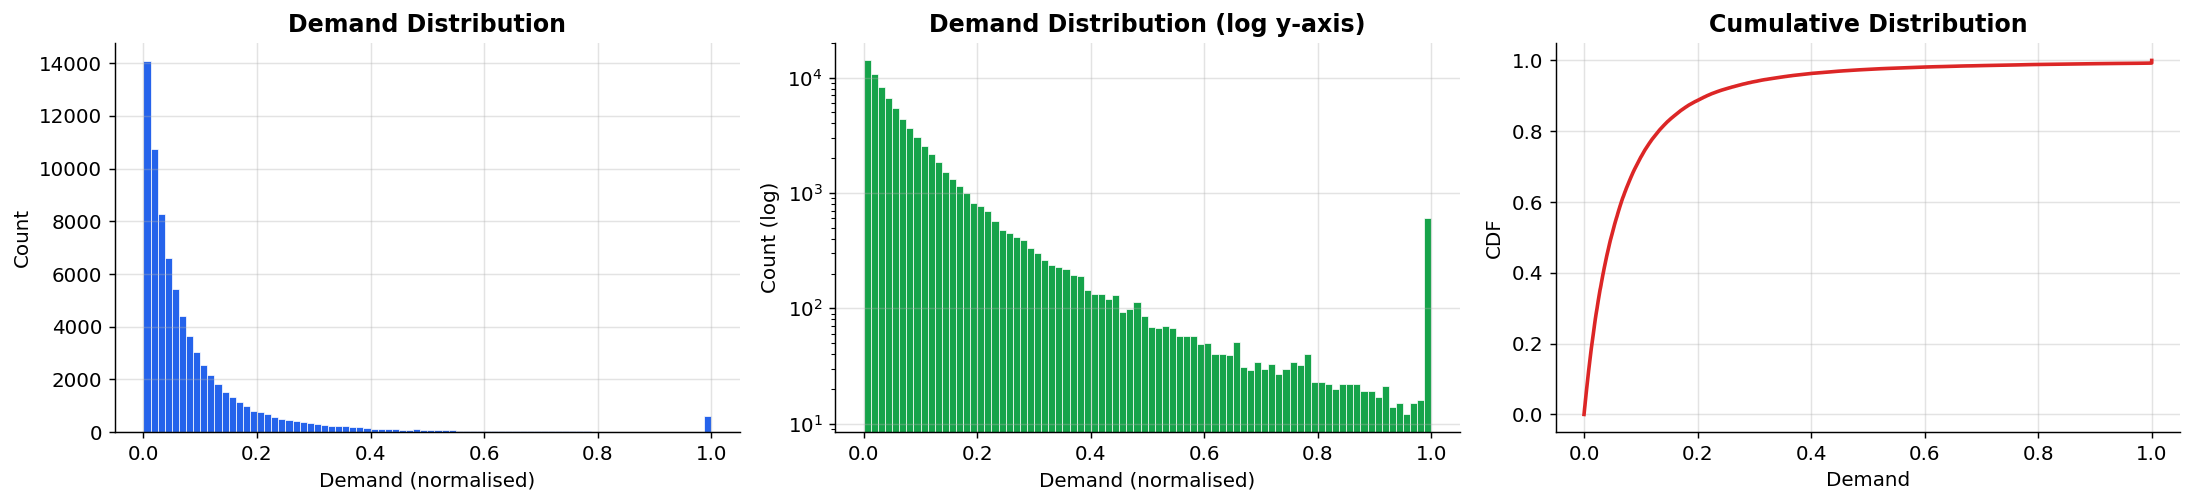

count    77299.0000
mean         0.0939
std          0.1422
min          0.0000
25%          0.0182
50%          0.0478
75%          0.1086
max          1.0000
Name: demand, dtype: float64


In [7]:
# ──Target Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(train['demand'], bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Demand Distribution', fontweight='bold')
axes[0].set_xlabel('Demand (normalised)')
axes[0].set_ylabel('Count')

# Log-scale
axes[1].hist(train['demand'], bins=80, color=PALETTE[1], edgecolor='white', linewidth=0.4, log=True)
axes[1].set_title('Demand Distribution (log y-axis)', fontweight='bold')
axes[1].set_xlabel('Demand (normalised)')
axes[1].set_ylabel('Count (log)')

# CDF
sorted_d = np.sort(train['demand'])
axes[2].plot(sorted_d, np.linspace(0, 1, len(sorted_d)), color=PALETTE[2], linewidth=2)
axes[2].set_title('Cumulative Distribution', fontweight='bold')
axes[2].set_xlabel('Demand')
axes[2].set_ylabel('CDF')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_target_distribution.png'), bbox_inches='tight')
plt.show()

print(train['demand'].describe().round(4))


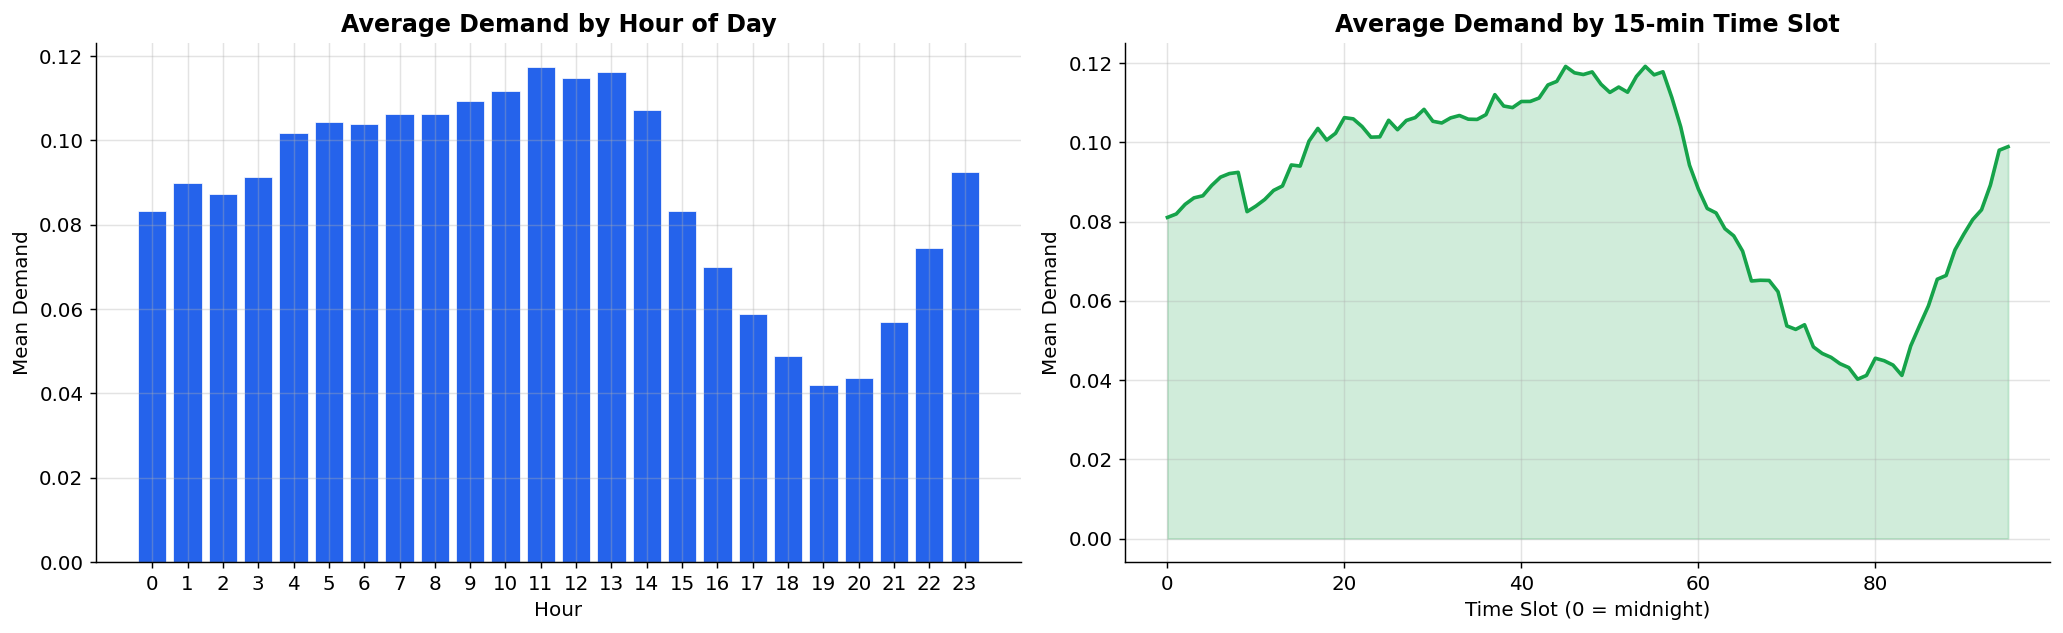

In [8]:
# ── Temporal Patterns ───────────────────────────────────────────────────
# Parse timestamp first (needed for EDA)
def parse_tmin(df):
    parts = df['timestamp'].astype(str).str.split(':', expand=True)
    df['hour']      = pd.to_numeric(parts[0], errors='coerce').fillna(0).clip(0, 23).astype(int)
    df['minute']    = pd.to_numeric(parts[1], errors='coerce').fillna(0).clip(0, 59).astype(int)
    df['tmin']      = (df['hour'] * 60 + df['minute']).astype(np.float32)
    df['time_slot'] = (df['hour'] * 4 + df['minute'] // 15).astype(np.int16)
    return df

train = parse_tmin(train)
test  = parse_tmin(test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly mean demand
hourly = train.groupby('hour')['demand'].mean()
axes[0].bar(hourly.index, hourly.values, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Average Demand by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Demand')
axes[0].set_xticks(range(0, 24))

# 15-min slot demand
slot_dem = train.groupby('time_slot')['demand'].mean()
axes[1].plot(slot_dem.index, slot_dem.values, color=PALETTE[1], linewidth=2)
axes[1].fill_between(slot_dem.index, slot_dem.values, alpha=0.2, color=PALETTE[1])
axes[1].set_title('Average Demand by 15-min Time Slot', fontweight='bold')
axes[1].set_xlabel('Time Slot (0 = midnight)')
axes[1].set_ylabel('Mean Demand')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_temporal_patterns.png'), bbox_inches='tight')
plt.show()


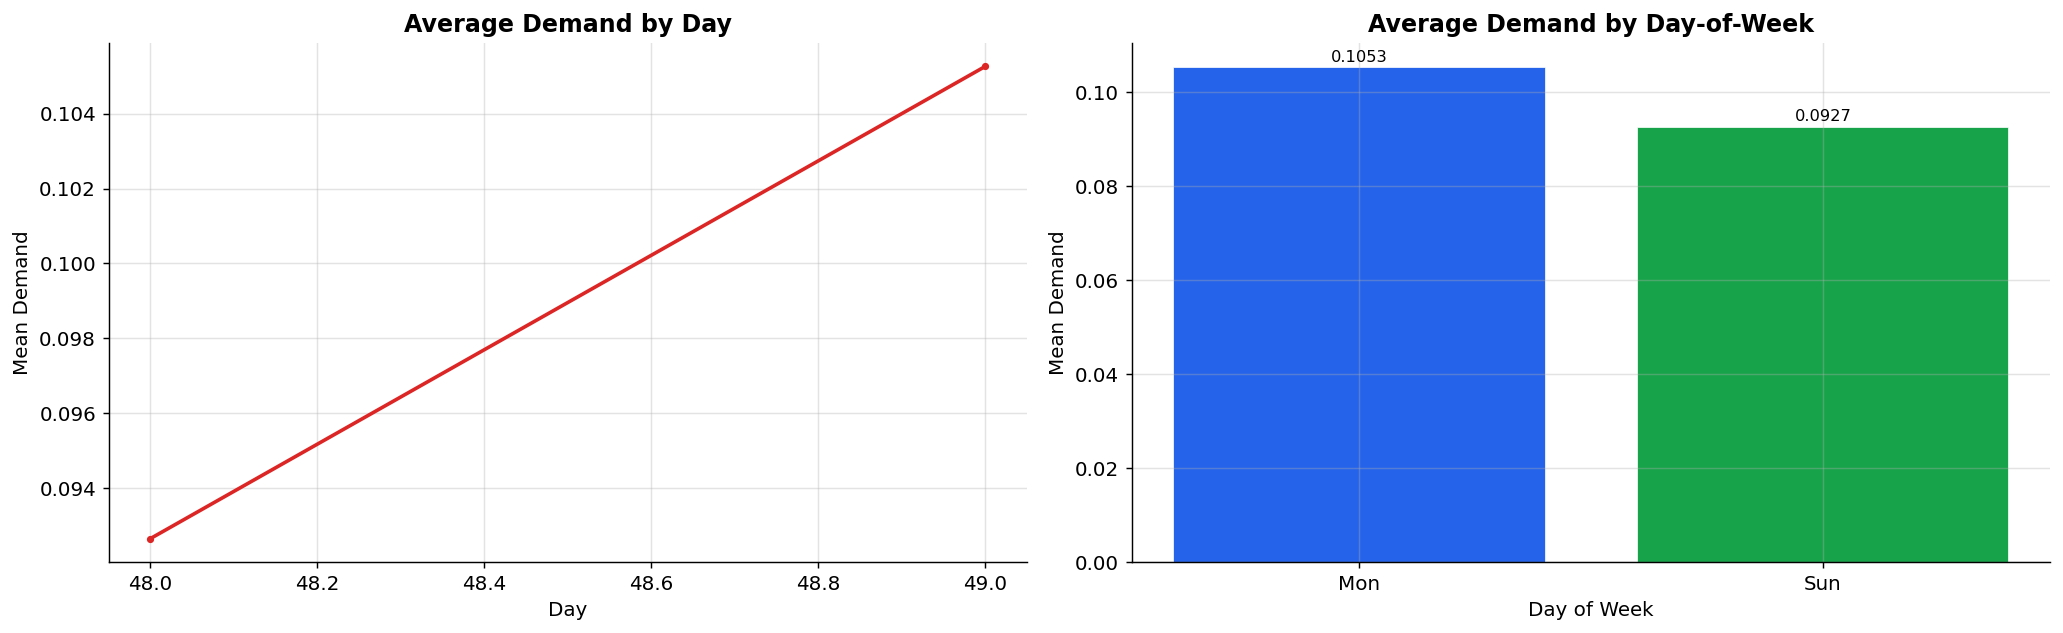

In [9]:
# ── Daily Trends ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

daily = train.groupby('day')['demand'].mean()
axes[0].plot(daily.index, daily.values, color=PALETTE[2], linewidth=2, marker='o', markersize=3)
axes[0].set_title('Average Demand by Day', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Mean Demand')

# Day-of-week (day % 7)
train['dow'] = (train['day'] % 7).astype(int)
dow_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
dow_d = train.groupby('dow')['demand'].mean()
bars = axes[1].bar([dow_map[i] for i in dow_d.index], dow_d.values,
                   color=PALETTE[:7], edgecolor='white', linewidth=0.4)
axes[1].set_title('Average Demand by Day-of-Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Demand')
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_daily_trends.png'), bbox_inches='tight')
plt.show()


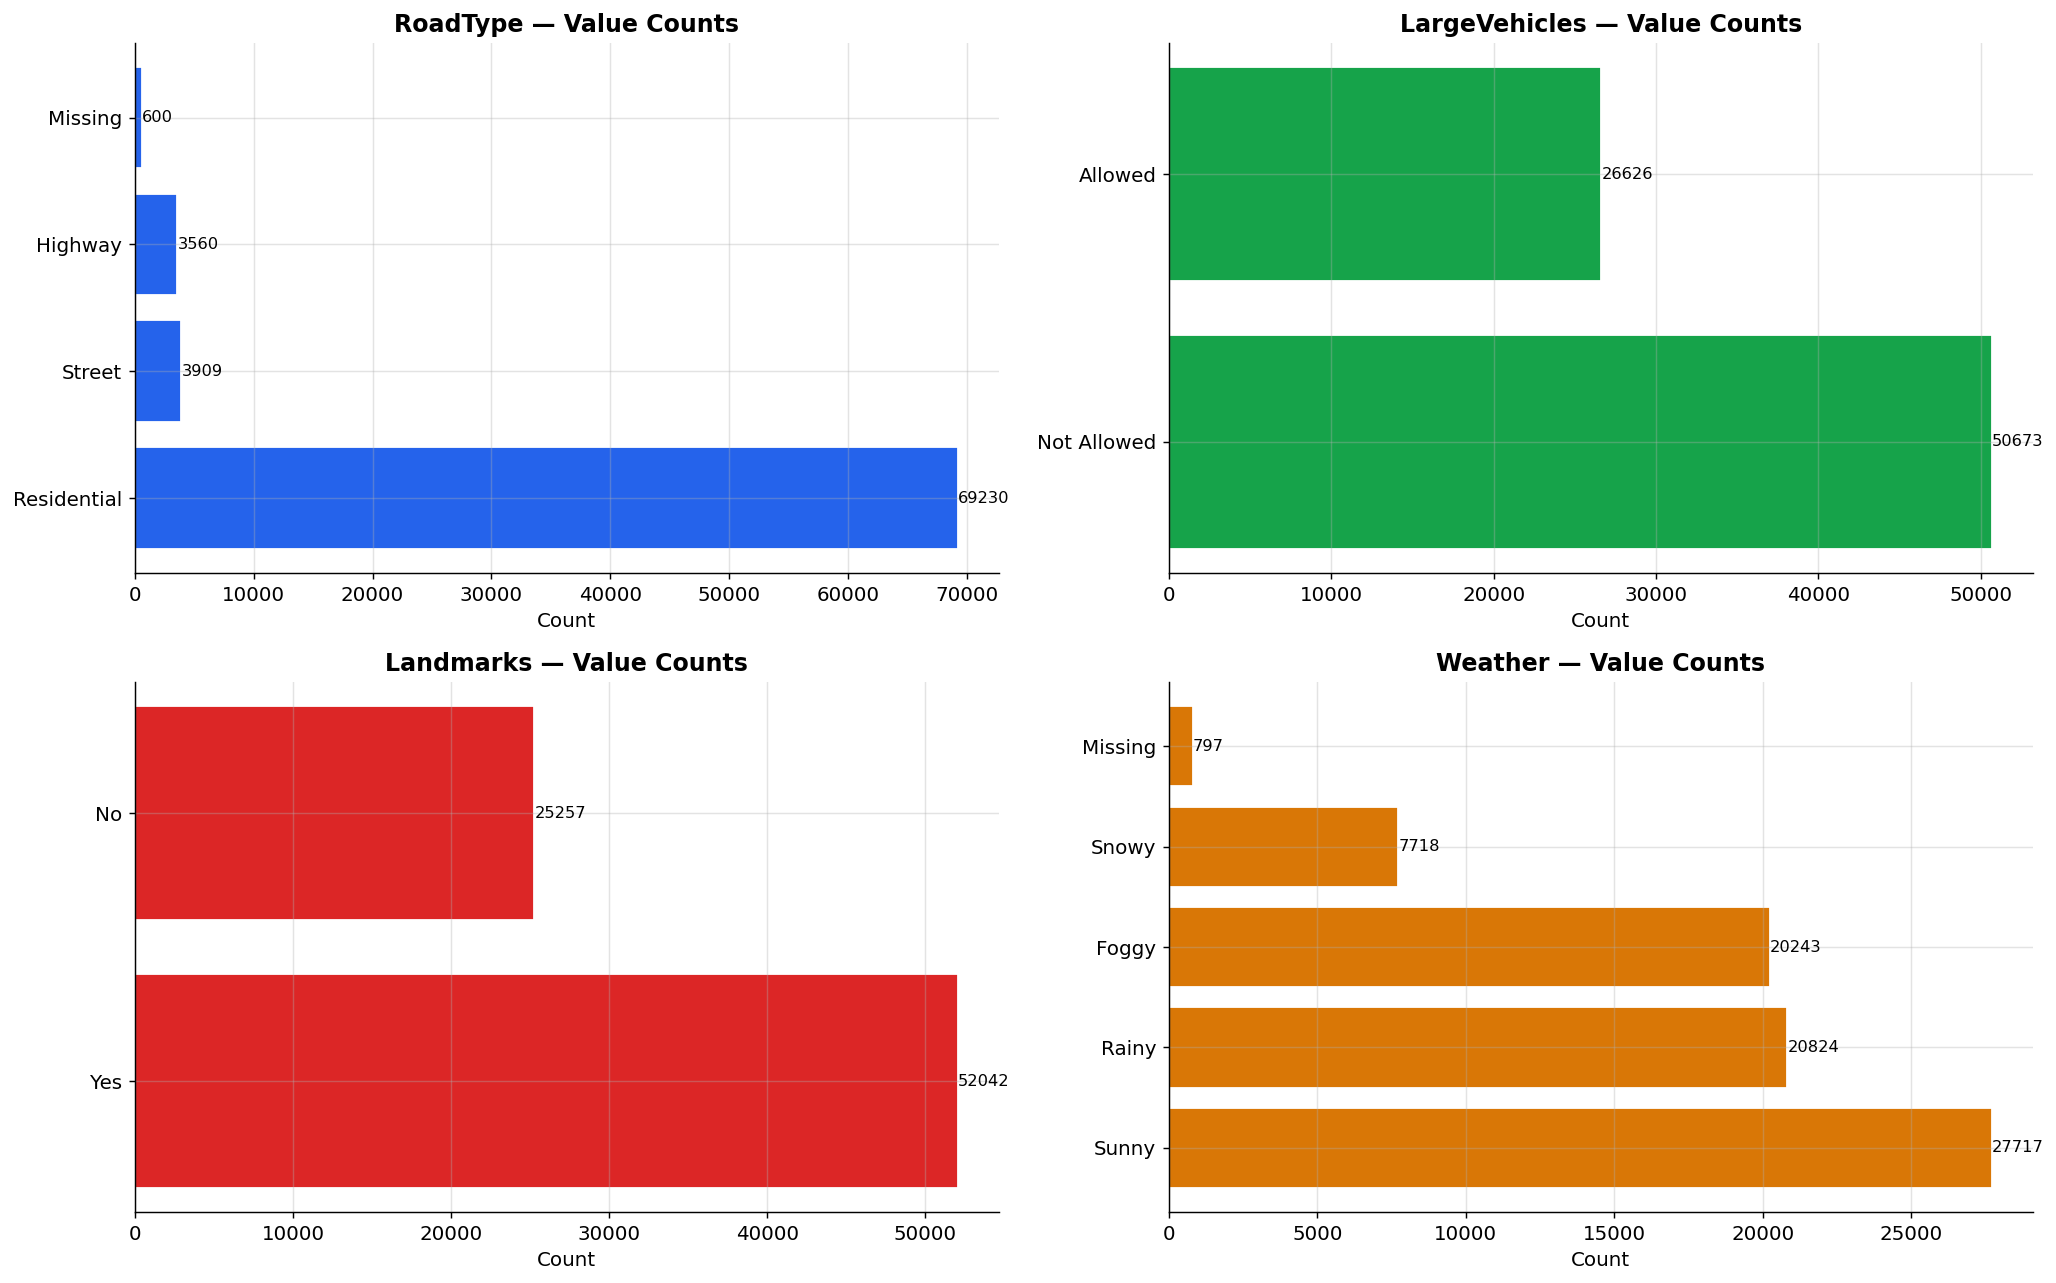

In [10]:
# ── Categorical Feature Distributions ───────────────────────────────────
CAT_COLS = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    vc = train[col].fillna('Missing').value_counts()
    axes[i].barh(vc.index, vc.values, color=PALETTE[i % len(PALETTE)], edgecolor='white')
    axes[i].set_title(f'{col} — Value Counts', fontweight='bold')
    axes[i].set_xlabel('Count')
    for j, (idx, val) in enumerate(vc.items()):
        axes[i].text(val + 10, j, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_categorical_features.png'), bbox_inches='tight')
plt.show()


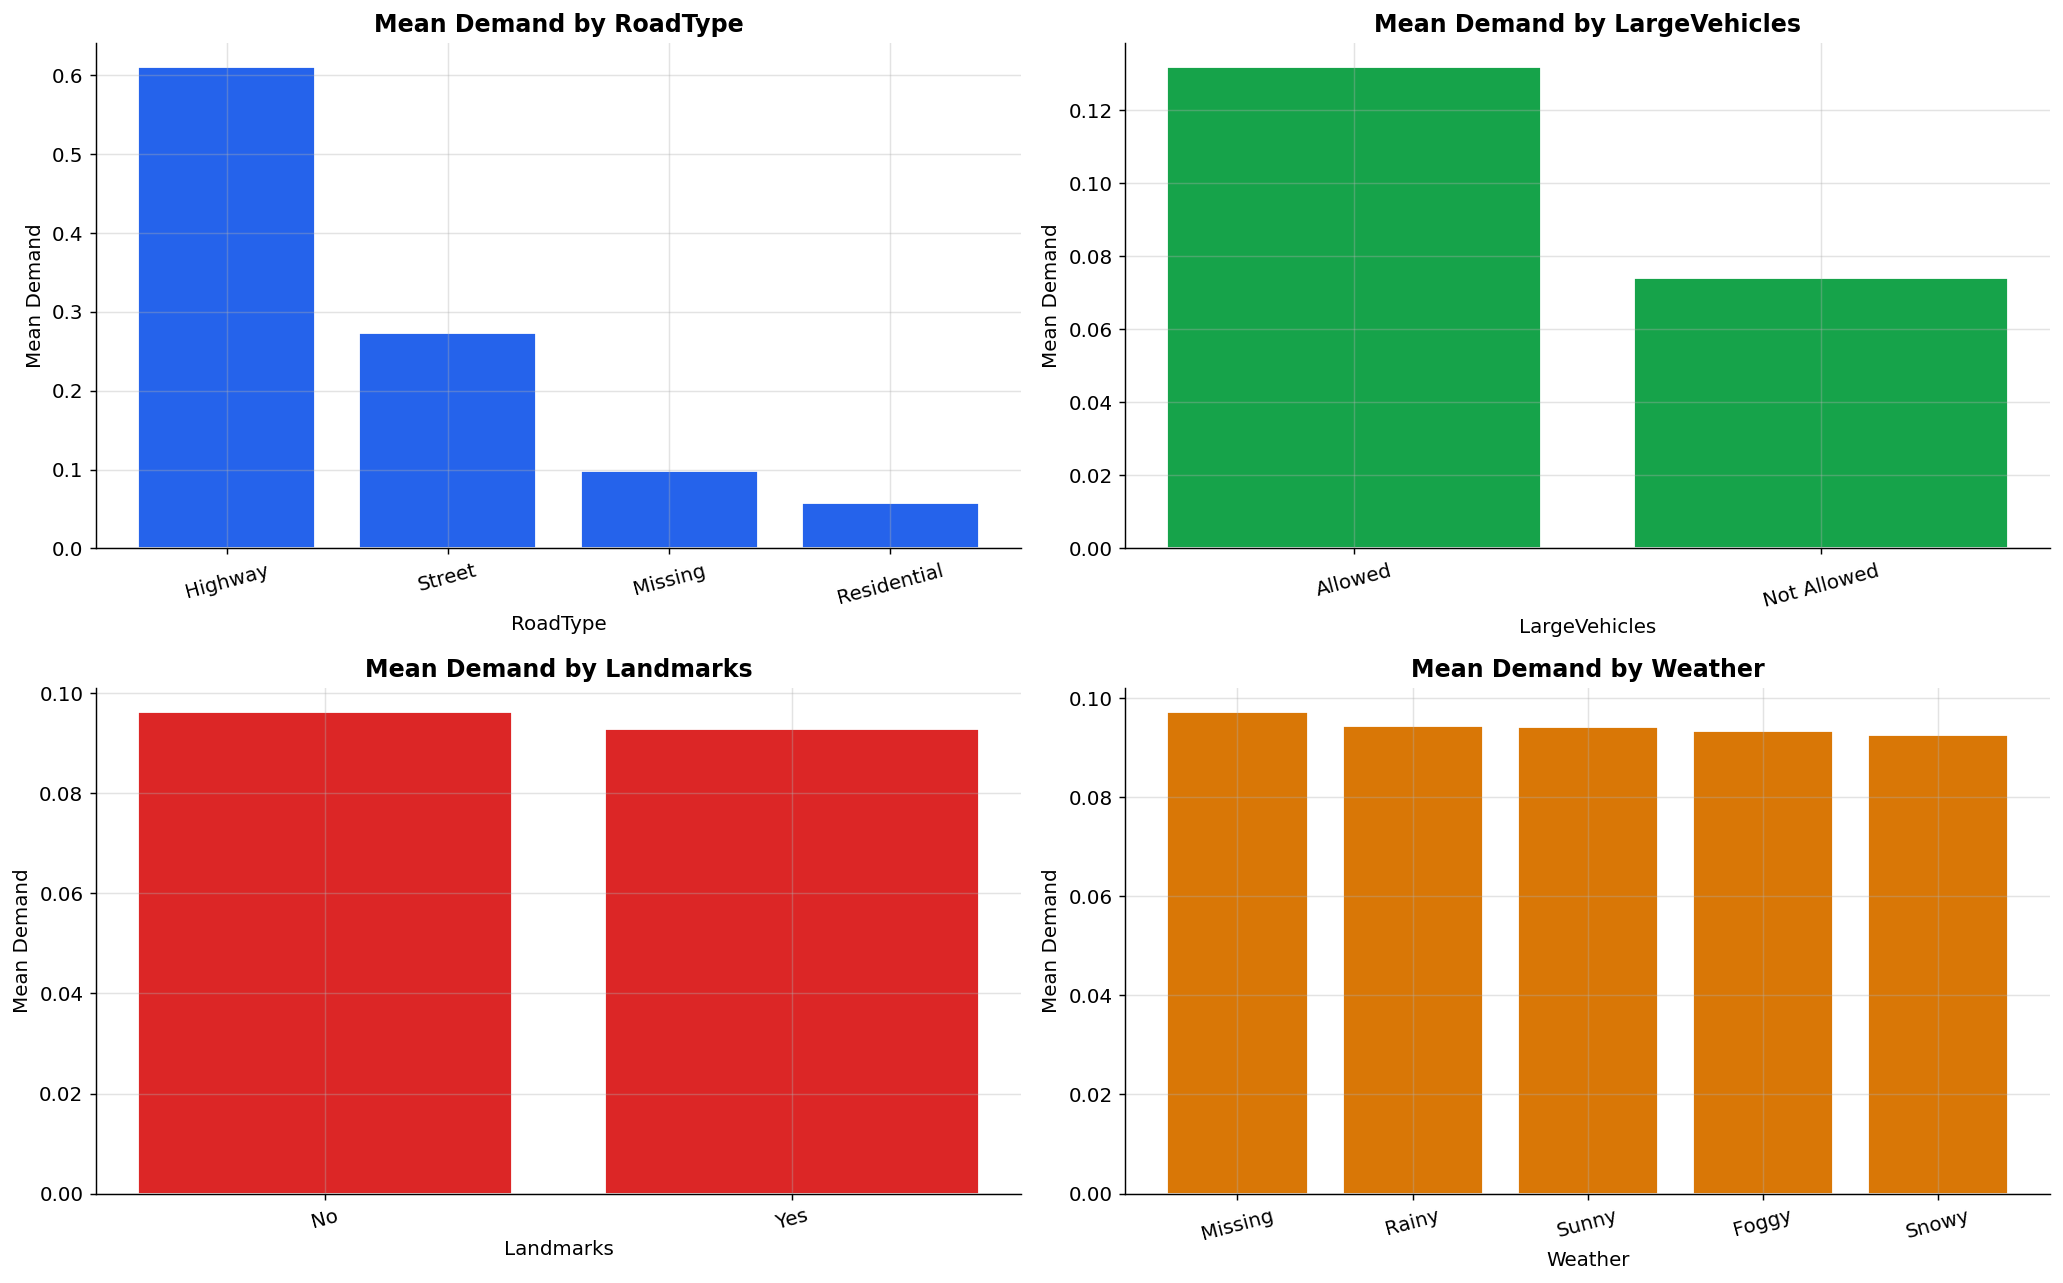

In [11]:
# ── Demand by Categorical Features ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    grp = train.groupby(train[col].fillna('Missing'))['demand'].mean().sort_values(ascending=False)
    axes[i].bar(grp.index.astype(str), grp.values, color=PALETTE[i % len(PALETTE)], edgecolor='white')
    axes[i].set_title(f'Mean Demand by {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Mean Demand')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_demand_by_category.png'), bbox_inches='tight')
plt.show()


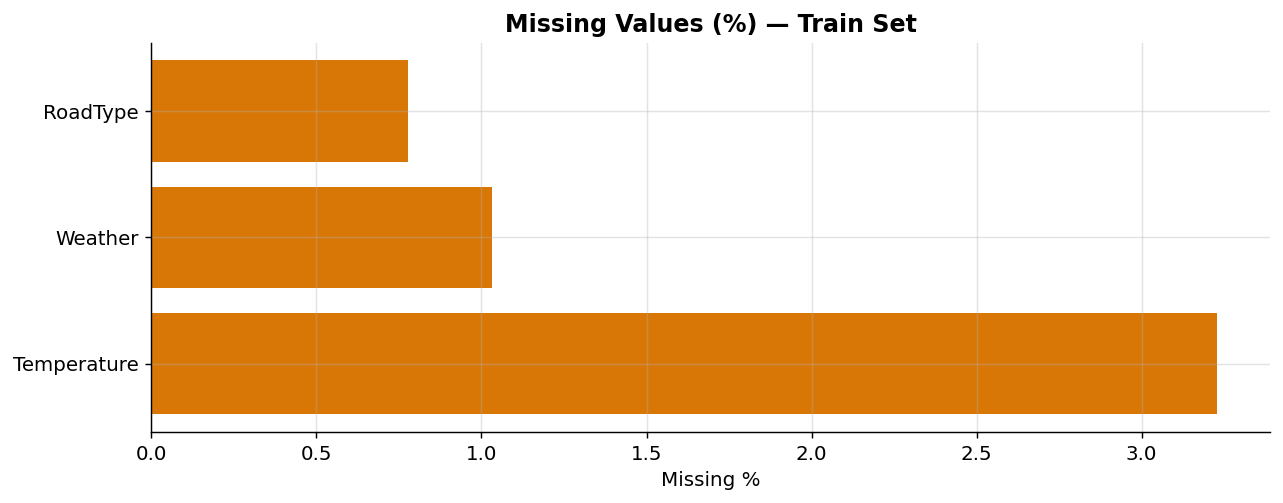


Missing value counts:
 RoadType        600
Temperature    2495
Weather         797
dtype: int64


In [12]:
# ── Missing Values Heatmap ──────────────────────────────────────────────
missing = train.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing.index, missing.values * 100, color=PALETTE[3])
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values (%) — Train Set', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, 'eda_missing_values.png'), bbox_inches='tight')
    plt.show()
else:
    print("No missing values in the training set (after excluding demand).")

print("\nMissing value counts:\n", train.isna().sum()[train.isna().sum() > 0])


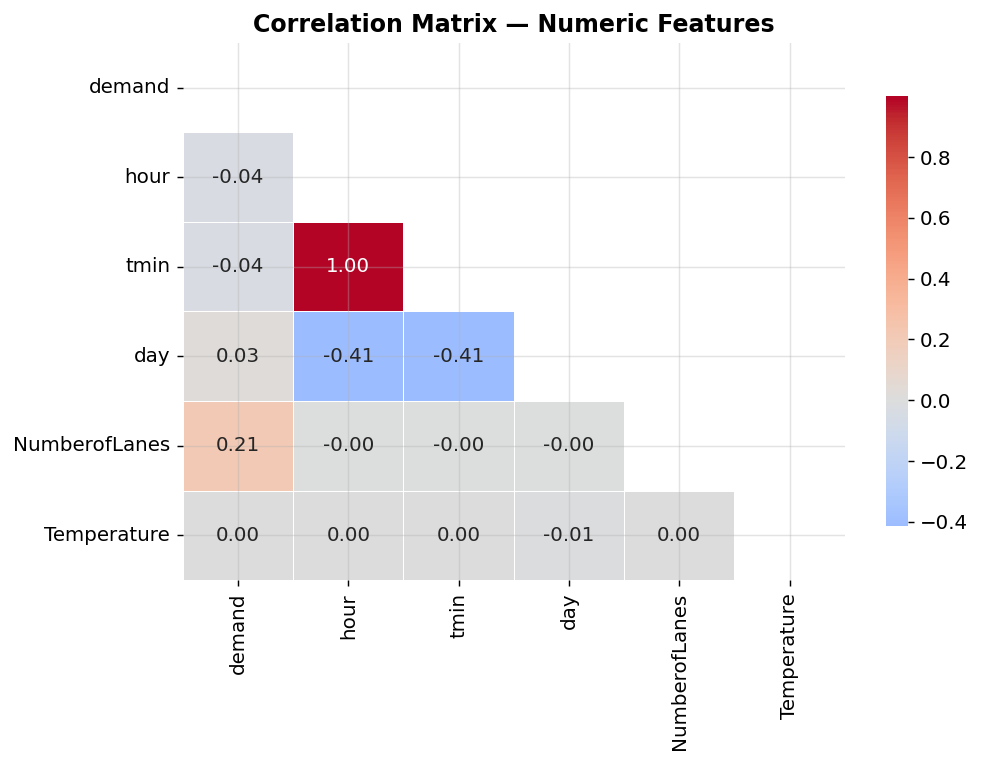

In [13]:
# ── Correlation Matrix ───────────────────────────────────────────────────
num_cols = ['demand', 'hour', 'tmin', 'day', 'NumberofLanes', 'Temperature']
corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eda_correlation_matrix.png'), bbox_inches='tight')
plt.show()


# **Feature Engineering**

Feature engineering is the most critical component of the Traffic Demand Prediction pipeline. The objective is to transform raw temporal, spatial, traffic, and environmental information into highly informative signals that capture underlying traffic dynamics.

The final feature set combines domain knowledge, geographical intelligence, temporal cyclicity, historical demand patterns, and interaction-based representations to maximize predictive performance.

---

## Geospatial Intelligence

The original location information is provided as Geohash strings. To extract meaningful spatial information, each geohash was decoded into its corresponding:

* Latitude (`lat`)
* Longitude (`lon`)

This transformation converts location identifiers into continuous geographic coordinates, enabling the model to learn spatial demand patterns directly.

### Geographic Clustering

To capture regional traffic behavior, K-Means clustering (`k = 20`) was applied to latitude and longitude coordinates.

This generated a new feature:

* `geo_cluster`

which groups nearby road segments into common traffic zones.

Benefits include:

* Learning neighborhood-level traffic characteristics.
* Capturing regional demand hotspots.
* Reducing geographical sparsity.
* Improving spatial generalization.

---

## Historical Demand Signal

Traffic demand typically exhibits strong temporal repetition.

To exploit this behavior, a historical lag feature was created:

### Day-48 Lag Feature

`d48_demand`

This feature represents the demand observed at the same:

* Geohash location
* Time-of-day

on Day 48.

Special care was taken to avoid data leakage by masking Day-48 observations during training.

This feature provides a powerful historical reference signal and often becomes one of the strongest predictors in traffic forecasting tasks.

---

## Temporal Feature Engineering

Traffic demand is inherently cyclical and highly dependent on time.

Multiple temporal representations were generated.

### Basic Time Features

* Hour
* Minute
* Time since midnight (`tmin`)
* 15-minute time slots (`time_slot`)

These features allow the model to capture both coarse and fine-grained temporal variations.

### Calendar Features

* Day of Week (`dow`)
* Weekend Indicator (`is_weekend`)

These variables capture recurring weekly traffic patterns.

---

## Harmonic Time Encoding

Traditional time representations treat midnight and 11 PM as distant values despite being adjacent in reality.

To preserve cyclic behavior, harmonic encoding was applied:

* `sin1`, `cos1`
* `sin2`, `cos2`
* `sin3`, `cos3`

representing first, second, and third-order temporal harmonics.

These features allow the model to learn:

* Daily periodicity
* Rush-hour cycles
* Repeating traffic rhythms

without introducing artificial discontinuities.

---

## Peak Traffic Indicators

Domain-specific traffic flags were introduced to explicitly identify important traffic periods.

### Peak Period Features

* `peak_am`
* `peak_pm`
* `peak_noon`

### Traffic Session Features

* `morning`
* `afternoon`
* `evening`
* `night`

### Low Activity Feature

* `off_peak`

These binary indicators help the model quickly distinguish between high-demand and low-demand traffic windows.

---

## Spatial–Temporal Interaction Features

Traffic behavior depends not only on location or time individually, but also on their interaction.

To capture these relationships, several composite features were created:

| Feature        | Description                      |
| -------------- | -------------------------------- |
| `cluster_hour` | Geographic cluster × hour        |
| `cluster_dow`  | Geographic cluster × day-of-week |
| `lat_tmin`     | Latitude × time                  |
| `lon_tmin`     | Longitude × time                 |
| `hour_slot`    | Hour × 15-minute slot            |

These features help model localized traffic patterns that vary throughout the day.

---

## Infrastructure and Context Features

Road capacity and environmental conditions strongly influence traffic demand.

### Road Capacity Features

* `NumberofLanes`
* `high_capacity`

The `high_capacity` flag identifies roads with four or more lanes, serving as a proxy for traffic carrying capacity.

### Environmental Features

* `Temperature`
* `Temp_missing`

Missing temperature values were imputed using the training median while preserving missingness information through a dedicated indicator feature.

---

## Binary Context Encoding

Several categorical traffic attributes were converted into machine-learning-friendly binary variables.

### Large Vehicle Access

`LargeVehicles_b`

Encodes whether heavy vehicles are allowed on a road segment.

### Landmark Presence

`Landmarks_b`

Indicates the presence of nearby landmarks that may influence traffic flow.

These transformations simplify learning while retaining important contextual information.

---

## Categorical Location Features

The following variables were preserved as categorical features:

* RoadType
* Weather
* LargeVehicles
* Landmarks
* Geohash (`gh6`)

These are utilized directly by models such as LightGBM that support native categorical handling.

---

## Feature Engineering Summary

The final feature engineering framework combines five complementary information sources:

| Feature Group           | Purpose                                         |
| ----------------------- | ----------------------------------------------- |
| Temporal Features       | Capture daily and weekly traffic cycles         |
| Harmonic Features       | Model cyclic time behavior                      |
| Spatial Features        | Learn geographical demand patterns              |
| Historical Features     | Leverage recurring traffic demand               |
| Interaction Features    | Capture localized spatio-temporal dynamics      |
| Infrastructure Features | Represent road capacity and traffic constraints |
| Environmental Features  | Model weather-related demand variations         |

This multi-layered feature engineering strategy transforms raw transportation data into a high-dimensional predictive representation capable of capturing complex traffic demand behavior across space and time.


In [14]:
# ── Geohash Decoding ────────────────────────────────────────────────────
all_geo = pd.concat([train['geohash'], test['geohash']]).unique()

def decode_geo(g):
    try:
        lat, lon = geohash2.decode_exactly(g)[:2]
        return float(lat), float(lon)
    except:
        return np.nan, np.nan

GH2LL = {g: decode_geo(g) for g in all_geo}

for df in [train, test]:
    df['lat'] = df['geohash'].map(lambda g: GH2LL[g][0]).astype(np.float32)
    df['lon'] = df['geohash'].map(lambda g: GH2LL[g][1]).astype(np.float32)

print(f"Decoded {len(GH2LL)} unique geohashes.")
print(f"Lat range : {train['lat'].min():.4f} → {train['lat'].max():.4f}")
print(f"Lon range : {train['lon'].min():.4f} → {train['lon'].max():.4f}")


Decoded 1259 unique geohashes.
Lat range : -5.4849 → -5.2377
Lon range : 90.5878 → 90.9723


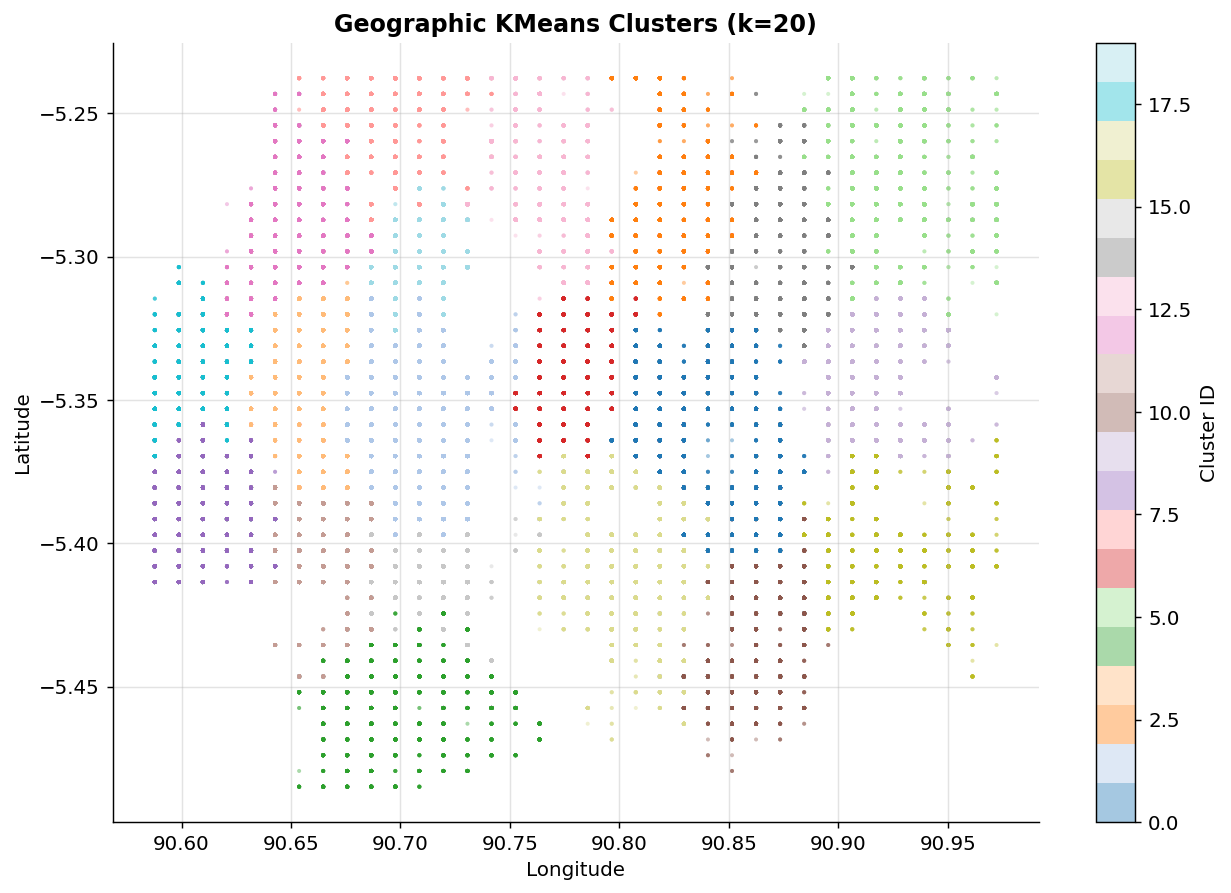

Cluster distribution:
geo_cluster
1     7588
0     6375
5     4792
3     4572
17    4563
2     4309
8     4289
12    4091
9     3901
4     3755
Name: count, dtype: int64


In [15]:
# ── Geographic Clustering (KMeans k=20) ─────────────────────────────────
km = KMeans(n_clusters=20, random_state=SEED, n_init=10)
km.fit(train[['lat', 'lon']].fillna(0))
train['geo_cluster'] = km.predict(train[['lat', 'lon']].fillna(0)).astype(np.int16)
test['geo_cluster']  = km.predict(test[['lat', 'lon']].fillna(0)).astype(np.int16)

# Visualise clusters
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(train['lon'], train['lat'],
                     c=train['geo_cluster'], cmap='tab20',
                     s=5, alpha=0.4, linewidths=0)
plt.colorbar(scatter, ax=ax, label='Cluster ID')
ax.set_title('Geographic KMeans Clusters (k=20)', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'feat_geo_clusters.png'), bbox_inches='tight')
plt.show()

print(f"Cluster distribution:\n{train['geo_cluster'].value_counts().head(10)}")
''

In [16]:
# ── Day-48 Lag Feature ──────────────────────────────────────────────────
d48 = train[train['day'] == 48].set_index(['geohash', 'tmin'])['demand']

def add_d48_lag(df, is_train=True):
    key = list(zip(df['geohash'].values, df['tmin'].values))
    lag = np.array([d48.get(k, np.nan) for k in key], dtype=np.float32)
    if is_train:
        lag[df['day'].values == 48] = np.nan   # avoid data leakage on day 48
    df['d48_demand'] = lag

add_d48_lag(train, is_train=True)
add_d48_lag(test,  is_train=False)

coverage_tr = train['d48_demand'].notna().mean()
coverage_te = test['d48_demand'].notna().mean()
print(f"Day-48 lag coverage — Train: {coverage_tr:.1%} | Test: {coverage_te:.1%}")

# Correlation of lag with actual demand
valid = train[train['d48_demand'].notna()]
corr_val = valid['demand'].corr(valid['d48_demand'])
print(f"Correlation(demand, d48_demand) on non-null rows: {corr_val:.4f}")


Day-48 lag coverage — Train: 8.3% | Test: 88.9%
Correlation(demand, d48_demand) on non-null rows: 0.7924


In [17]:
# ── Static Feature Construction ─────────────────────────────────────────
CAT_COLS = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

def build_static_features(df, train_ref):
    df = df.copy()

    # Harmonic time features
    for k in (1, 2, 3):
        df[f'sin{k}'] = np.sin(2 * np.pi * k * df['tmin'] / 1440).astype(np.float32)
        df[f'cos{k}'] = np.cos(2 * np.pi * k * df['tmin'] / 1440).astype(np.float32)

    # Calendar
    df['dow']        = (df['day'] % 7).astype(np.int8)
    df['is_weekend'] = (df['dow'] >= 5).astype(np.int8)
    df['d_sin']      = np.sin(2 * np.pi * df['day'] / 50).astype(np.float32)
    df['d_cos']      = np.cos(2 * np.pi * df['day'] / 50).astype(np.float32)

    # Peak / period flags
    h = df['hour'].values
    df['peak_am']   = ((h >= 7)  & (h <= 9)).astype(np.int8)
    df['peak_pm']   = ((h >= 17) & (h <= 19)).astype(np.int8)
    df['peak_noon'] = ((h >= 11) & (h <= 13)).astype(np.int8)
    df['off_peak']  = ((h >= 0)  & (h <= 5)).astype(np.int8)
    df['morning']   = ((h >= 5)  & (h <= 10)).astype(np.int8)
    df['afternoon'] = ((h >= 12) & (h <= 17)).astype(np.int8)
    df['evening']   = ((h >= 18) & (h <= 23)).astype(np.int8)
    df['night']     = ((h >= 0)  & (h <= 4)).astype(np.int8)

    # Interaction features
    df['cluster_hour'] = (df['geo_cluster'] * df['hour']).astype(np.float32)
    df['cluster_dow']  = (df['geo_cluster'] * df['dow']).astype(np.float32)
    df['lat_tmin']     = (df['lat'] * df['tmin']).astype(np.float32)
    df['lon_tmin']     = (df['lon'] * df['tmin']).astype(np.float32)
    df['hour_slot']    = (df['hour'] * df['time_slot']).astype(np.int32)

    # Road / weather
    df['NumberofLanes']   = df['NumberofLanes'].astype(np.float32)
    df['Temp_missing']    = df['Temperature'].isna().astype(np.float32)
    df['Temperature']     = df['Temperature'].fillna(train_ref['Temperature'].median()).astype(np.float32)
    df['LargeVehicles_b'] = (df['LargeVehicles'].astype(str).str.lower()
                              .map({'allowed': 1, 'not allowed': 0}).fillna(0).astype(np.int8))
    df['Landmarks_b']     = (df['Landmarks'].astype(str).str.lower()
                              .map({'yes': 1, 'no': 0}).fillna(0).astype(np.int8))
    df['high_capacity']   = (df['NumberofLanes'] >= 4).astype(np.int8)

    for c in CAT_COLS:
        df[c] = df[c].fillna('Missing').astype('category')

    df['gh6'] = df['geohash'].astype('category')

    return df

train_fe = build_static_features(train, train)
test_fe  = build_static_features(test,  train)

print("Static features built.")
print(f"   Train_fe shape: {train_fe.shape}")
print(f"   Test_fe  shape: {test_fe.shape}")


Static features built.
   Train_fe shape: (77299, 47)
   Test_fe  shape: (41778, 46)


In [18]:
# ── Feature Summary ─────────────────────────────────────────────────────
HARM_FEATS = [f'{p}{k}' for k in (1, 2, 3) for p in ('sin', 'cos')]
NUM_BASE   = (['lat', 'lon', 'tmin', 'hour', 'NumberofLanes', 'Temperature',
               'Temp_missing', 'dow', 'is_weekend', 'd_sin', 'd_cos',
               'peak_am', 'peak_pm', 'peak_noon', 'off_peak',
               'morning', 'afternoon', 'evening', 'night',
               'LargeVehicles_b', 'Landmarks_b', 'high_capacity',
               'geo_cluster', 'cluster_hour', 'cluster_dow',
               'lat_tmin', 'lon_tmin', 'hour_slot', 'd48_demand']
              + HARM_FEATS)

ALL_CATS   = CAT_COLS + ['gh6']
FEATS_LGB  = NUM_BASE + ALL_CATS       # LGB models with native categoricals
TE_FEATS   = ['gh_te', 'gh_std', 'gh_ts_te', 'rt_te', 'cluster_te', 'hour_te']
FEATS_TE   = NUM_BASE + TE_FEATS       # Numeric-only models with target encoding

y = train_fe['demand'].values.astype(np.float32)

print(f"Feature sets:")
print(f"  NUM_BASE  : {len(NUM_BASE)} features")
print(f"  FEATS_LGB : {len(FEATS_LGB)} features  (numeric + native categoricals)")
print(f"  FEATS_TE  : {len(FEATS_TE)} features  (numeric + target-encoded)")
print(f"  Target (y): {y.shape[0]} samples | mean={y.mean():.4f} | std={y.std():.4f}")


Feature sets:
  NUM_BASE  : 35 features
  FEATS_LGB : 40 features  (numeric + native categoricals)
  FEATS_TE  : 41 features  (numeric + target-encoded)
  Target (y): 77299 samples | mean=0.0939 | std=0.1422


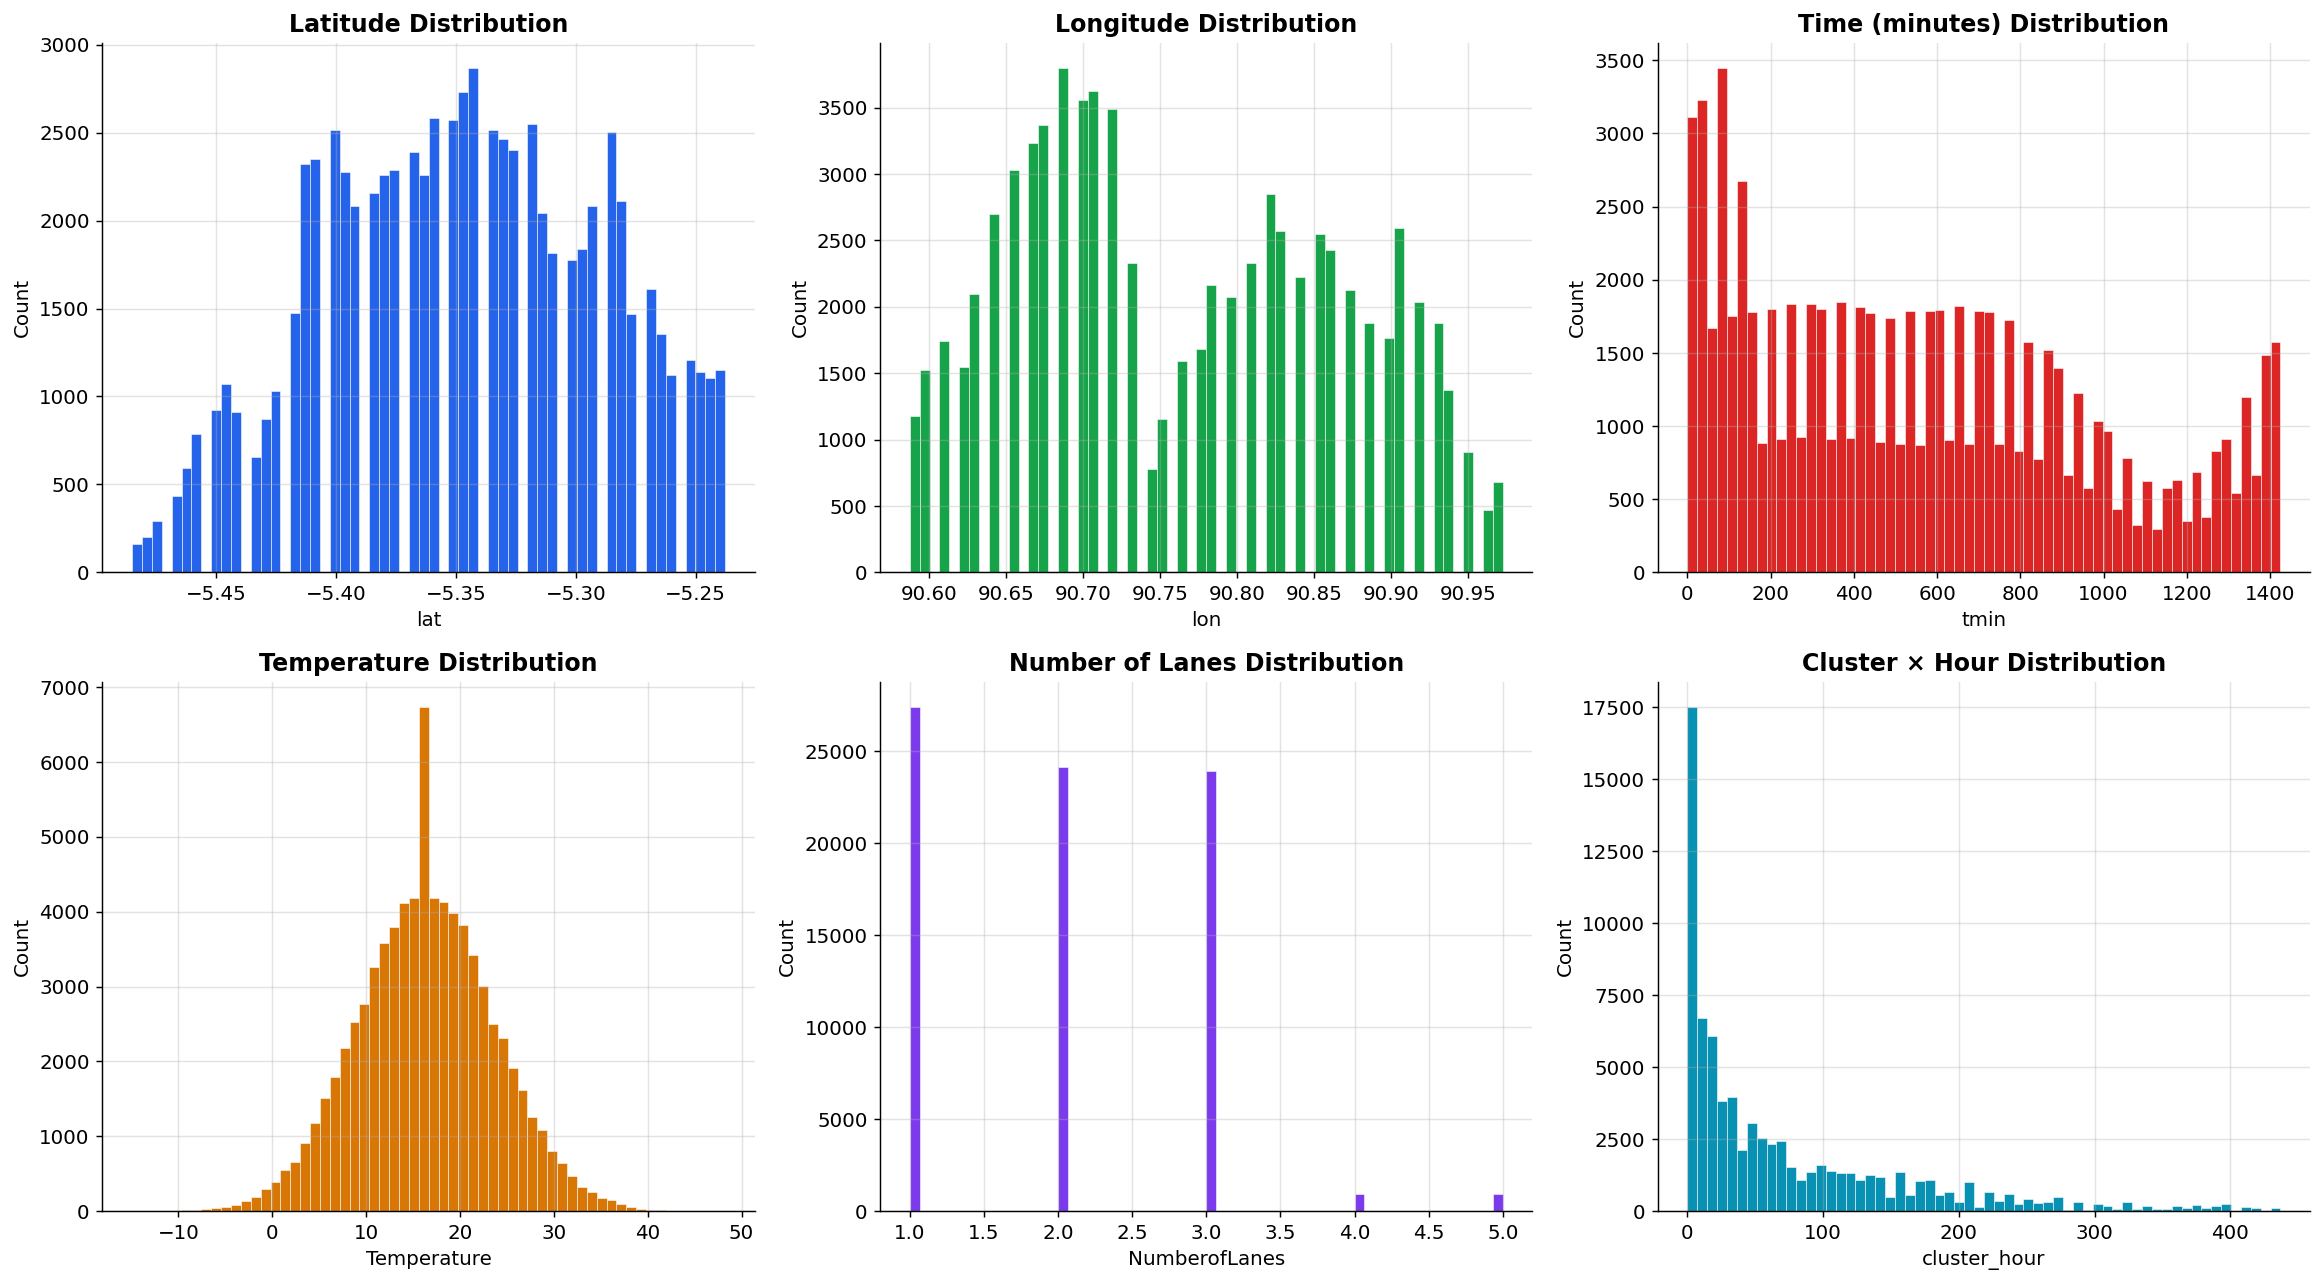

In [19]:
# ── Feature Visualisations ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

vis_feats = ['lat', 'lon', 'tmin', 'Temperature', 'NumberofLanes', 'cluster_hour']
titles    = ['Latitude', 'Longitude', 'Time (minutes)', 'Temperature', 'Number of Lanes', 'Cluster × Hour']

for i, (feat, title) in enumerate(zip(vis_feats, titles)):
    axes[i].hist(train_fe[feat].dropna(), bins=60, color=PALETTE[i], edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{title} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'feat_numeric_distributions.png'), bbox_inches='tight')
plt.show()


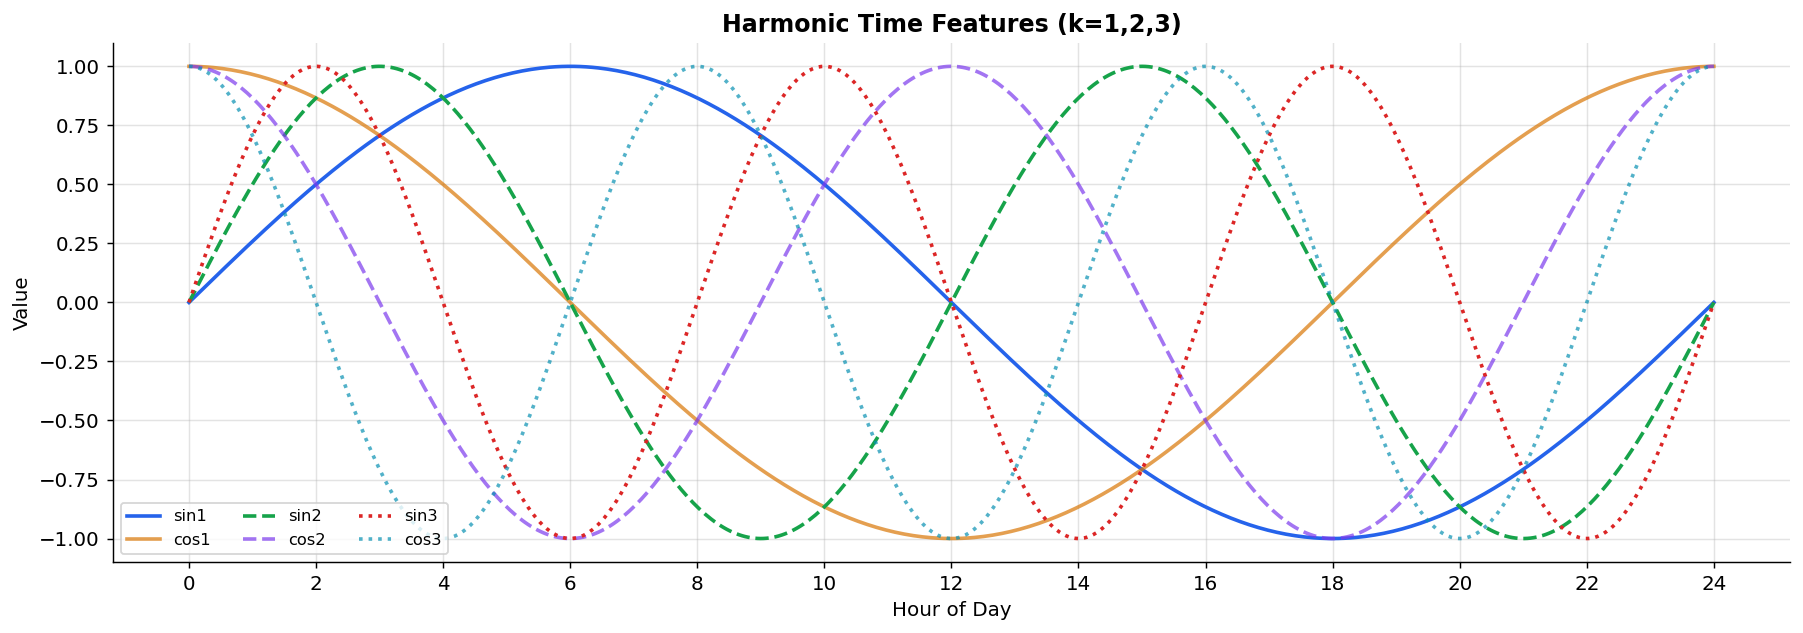

In [20]:
# ── Harmonic Features Visualisation ─────────────────────────────────────
tmin_range = np.linspace(0, 1440, 500)
fig, ax = plt.subplots(figsize=(14, 5))

styles = ['-', '--', ':']
for k in (1, 2, 3):
    ax.plot(tmin_range / 60, np.sin(2 * np.pi * k * tmin_range / 1440),
            label=f'sin{k}', linewidth=2, linestyle=styles[k-1], color=PALETTE[k-1])
    ax.plot(tmin_range / 60, np.cos(2 * np.pi * k * tmin_range / 1440),
            label=f'cos{k}', linewidth=2, linestyle=styles[k-1], color=PALETTE[k+2], alpha=0.7)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Value')
ax.set_title('Harmonic Time Features (k=1,2,3)', fontweight='bold')
ax.legend(ncol=3, fontsize=9)
ax.set_xticks(range(0, 25, 2))
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'feat_harmonics.png'), bbox_inches='tight')
plt.show()


**Target Encoding (Fold-Safe & Leakage-Free)**

While categorical features such as geohash, road type, and geographic clusters contain valuable predictive information, directly using high-cardinality categories can lead to sparse representations and reduced model efficiency.

To address this, a fold-safe target encoding strategy was implemented. The objective is to replace categorical values with statistically meaningful representations derived from historical demand behavior while strictly preventing target leakage.

---

## Why Target Encoding?

Many categorical variables in the dataset exhibit strong relationships with traffic demand.

For example:

* Certain geohashes consistently experience higher traffic volumes.
* Some road types naturally carry more traffic than others.
* Specific geographic clusters act as congestion hotspots.
* Traffic demand varies significantly across different times of the day.

Target encoding converts these categorical identifiers into numerical features that directly capture such demand patterns.

---

## Smoothed Target Encoding

Instead of using raw category averages, smoothed target encoding was employed to improve robustness, particularly for categories with limited observations.

The encoding value is computed as:

$$
\hat{\mu}_k =
\frac{n_k \cdot \bar{y}_k + m \cdot \bar{y}_{\mathrm{global}}}
{n_k + m}
$$

Where:

Where:

* $\bar{y}_k$ = Mean demand of category $k$
* $n_k$ = Number of observations in category $k$
* $\bar{y}_{\mathrm{global}}$ = Global mean demand
* $m$ = Smoothing factor

This approach balances local category information with the overall dataset average.

### Benefits

* Reduces overfitting on rare categories.
* Produces stable estimates for low-frequency groups.
* Preserves meaningful category-specific demand patterns.
* Improves generalization on unseen data.

---

## Fold-Safe Implementation

A critical requirement of target encoding is preventing data leakage.

To ensure a realistic training environment:

1. Encoding statistics are computed only using the training portion of each fold.
2. Validation samples never contribute to their own encoded values.
3. The same fold-specific mappings are applied to validation and test datasets.
4. Unseen categories are assigned the global mean demand.

This guarantees that encoded features contain only information available at prediction time.

---

## Encoded Feature Set

### Geohash Target Encoding (`gh_te`)

Traffic demand often varies significantly across locations.

A smoothed mean demand value was computed for each geohash using a smoothing factor of **10**.

This feature captures location-specific traffic intensity and serves as one of the strongest spatial predictors.

---

### Geohash Demand Variability (`gh_std`)

In addition to average demand, the standard deviation of demand was computed for each geohash.

This feature measures traffic volatility and helps distinguish between:

* Consistently busy locations.
* Locations with highly fluctuating demand.

Missing values are replaced with zero for unseen locations.

---

### Geohash × Time Slot Encoding (`gh_ts_te`)

Traffic patterns depend on both location and time.

To capture localized temporal behavior, a combined encoding was created using:

* Geohash
* 15-minute time slot

with a smoothing factor of **5**.

This feature enables the model to learn patterns such as:

* Morning congestion at specific intersections.
* Evening demand peaks in business districts.
* Time-dependent traffic hotspots.

---

### Road Type Encoding (`rt_te`)

Different road categories exhibit distinct traffic characteristics.

A smoothed target encoding was generated for:

* Highways
* Urban roads
* Local roads
* Other road classes

using a smoothing factor of **20**.

This feature captures the inherent traffic-carrying behavior of each road type.

---

### Geographic Cluster Encoding (`cluster_te`)

The K-Means clustering process grouped nearby locations into traffic regions.

A target encoding was then computed for each geographic cluster using a smoothing factor of **15**.

This feature represents regional demand tendencies and complements the finer-grained geohash encodings.

---

### Hour-Based Encoding (`hour_te`)

Traffic demand follows strong daily cycles.

A target encoding was generated for each hour of the day using a smoothing factor of **25**.

This feature summarizes the average traffic behavior associated with specific hours while remaining robust to noise and data sparsity.

---

## Feature Summary

| Encoded Feature | Information Captured            | Smoothing |
| --------------- | ------------------------------- | --------- |
| `gh_te`         | Average demand by geohash       | 10        |
| `gh_std`        | Demand variability by geohash   | —         |
| `gh_ts_te`      | Demand by geohash and time slot | 5         |
| `rt_te`         | Demand by road type             | 20        |
| `cluster_te`    | Demand by geographic cluster    | 15        |
| `hour_te`       | Demand by hour of day           | 25        |

---

## Impact on Model Performance

Target encoding transforms high-cardinality categorical variables into dense numerical representations that directly reflect historical traffic behavior.

Combined with strict fold-wise computation, this approach provides:

* Strong predictive power.
* Reduced dimensionality.
* Better handling of sparse categories.
* Improved generalization.
* Complete protection against target leakage.

As a result, target-encoded features become a critical component of the final ensemble pipeline and contribute significantly to the model's overall predictive accuracy.


In [22]:
def smoothed_te(frame, key_cols, target_col, smoothing=10.0):
    grp    = frame.groupby(key_cols)[target_col]
    means  = grp.mean()
    counts = grp.count()
    glob   = frame[target_col].mean()
    return (means * counts + glob * smoothing) / (counts + smoothing), glob

def add_fold_te(A_tr, others):
    """Compute target encoding from A_tr and apply to A_tr + all frames in others."""
    all_frames = [A_tr] + list(others)

    enc_gh, glob_gh = smoothed_te(A_tr, 'geohash', '__y', smoothing=10.0)
    std_gh = A_tr.groupby('geohash')['__y'].std()
    for f in all_frames:
        f['gh_te']  = f['geohash'].map(enc_gh).fillna(glob_gh).astype(np.float32)
        f['gh_std'] = f['geohash'].map(std_gh).fillna(0.0).astype(np.float32)

    enc_gts, glob_gts = smoothed_te(A_tr, ['geohash', 'time_slot'], '__y', smoothing=5.0)
    for f in all_frames:
        idx = pd.MultiIndex.from_arrays([f['geohash'], f['time_slot']])
        f['gh_ts_te'] = idx.map(enc_gts).to_numpy(dtype=np.float32)
        f['gh_ts_te'] = pd.Series(f['gh_ts_te'], index=f.index).fillna(glob_gts).astype(np.float32)

    enc_rt, glob_rt = smoothed_te(A_tr, 'RoadType', '__y', smoothing=20.0)
    for f in all_frames:
        f['rt_te'] = f['RoadType'].astype(str).map(enc_rt).fillna(glob_rt).astype(np.float32)

    enc_cl, glob_cl = smoothed_te(A_tr, 'geo_cluster', '__y', smoothing=15.0)
    for f in all_frames:
        f['cluster_te'] = f['geo_cluster'].map(enc_cl).fillna(glob_cl).astype(np.float32)

    enc_h, glob_h = smoothed_te(A_tr, 'hour', '__y', smoothing=25.0)
    for f in all_frames:
        f['hour_te'] = f['hour'].map(enc_h).fillna(glob_h).astype(np.float32)

print("Target encoding functions defined (fold-safe, leak-free).")


Target encoding functions defined (fold-safe, leak-free).


**Model Training and Validation Framework**

To maximize predictive performance while ensuring robustness and generalization, a diverse ensemble of machine learning models was trained using a **5-Fold Cross-Validation (CV)** framework.

The strategy combines multiple gradient boosting algorithms, bagging methods, and tree-based ensembles, allowing the pipeline to capture different aspects of the traffic demand signal while reducing model-specific bias.

---

## Cross-Validation Strategy

A **5-Fold K-Fold Cross-Validation** procedure was employed.

For each fold:

1. The dataset is split into training and validation subsets.
2. Fold-safe target encoding is computed exclusively from the training portion.
3. All models are trained independently.
4. Predictions are generated on the validation fold.
5. Out-of-Fold (OOF) predictions are stored.
6. Test-set predictions are accumulated and averaged across folds.

This process ensures:

* Reliable performance estimation.
* Reduced overfitting.
* Robust model comparison.
* High-quality ensemble construction.

---

## Model Portfolio

Rather than relying on a single algorithm, nine complementary models were trained.

### A. LightGBM Aggressive

A high-capacity LightGBM configuration designed to capture complex nonlinear traffic patterns.

**Characteristics**

* Large leaf space (`num_leaves = 150`)
* Deep decision boundaries
* Low learning rate
* Strong fitting capability

This model prioritizes predictive power and fine-grained pattern discovery.

---

### B. LightGBM Base

A balanced LightGBM configuration providing a trade-off between variance and bias.

**Characteristics**

* Moderate regularization
* Stable learning behavior
* Strong generalization capability

Serves as a reliable baseline gradient boosting model.

---

### C. LightGBM Light

A simplified LightGBM model trained on target-encoded features.

**Characteristics**

* Reduced complexity
* Faster convergence
* Lower overfitting tendency

Introduces additional diversity into the ensemble.

---

### D. LightGBM Very Light

An even more constrained LightGBM configuration.

**Characteristics**

* Smaller effective model capacity
* Higher robustness
* Different error profile

Provides complementary predictions relative to larger LightGBM models.

---

### E. LightGBM Alternate

A replica of the base LightGBM model trained with a different random seed.

Although structurally similar, the stochastic nature of boosting generates a distinct prediction pattern, improving ensemble diversity.

---

### F. XGBoost

XGBoost serves as an independent gradient boosting implementation.

**Characteristics**

* Histogram-based tree construction
* Strong regularization
* Excellent handling of nonlinear interactions

Provides an alternative boosting perspective compared to LightGBM.

---

### G. CatBoost

CatBoost introduces ordered boosting and advanced categorical feature handling.

**Characteristics**

* Reduced target leakage risk
* Stable gradient estimation
* Strong performance on structured tabular data

CatBoost often captures relationships missed by conventional boosting algorithms.

---

### H. Extra Trees Regressor

An ensemble of highly randomized decision trees.

**Characteristics**

* High prediction diversity
* Low correlation with boosting models
* Strong variance reduction when ensembled

Acts as a valuable non-boosting component.

---

### I. Histogram Gradient Boosting

Scikit-learn's optimized Gradient Boosting implementation.

**Characteristics**

* Histogram-based splits
* Efficient training
* Strong regularization

Provides an additional boosting architecture with a unique learning behavior.

---

## Training Configuration

Several measures were implemented to improve model quality and training efficiency.

### Early Stopping

For boosting models, training automatically terminates when validation performance stops improving.

Benefits include:

* Reduced overfitting
* Faster training
* Improved generalization

### Random Seed Diversification

Different random seeds were intentionally used across models to create diverse prediction patterns.

### Feature Selection

Two feature subsets were utilized:

| Feature Set   | Description                                      |
| ------------- | ------------------------------------------------ |
| **FEATS_LGB** | Numerical features + native categorical features |
| **FEATS_TE**  | Numerical features + target encoded features     |

This dual-representation approach allows different algorithms to exploit the data in their preferred format.

---

## Out-of-Fold Prediction Framework

For each model, predictions generated on validation folds were stored as:

$$
\text{OOF Predictions}
=
\left\{
\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_N
\right\}
$$

where every prediction is produced by a model that never observed that sample during training.

OOF predictions serve two critical purposes:

1. Unbiased performance estimation.
2. Ensemble weight optimization.

Because every sample is evaluated out-of-sample, OOF scores provide a realistic estimate of leaderboard performance.

---

## Evaluation Metric

Model performance was measured using the coefficient of determination ((R^2)):

$$
R^2
=
1 -
\frac{
\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{N}(y_i-\bar{y})^2
}
$$

Where:

* $y_i$ = Actual demand
* $\hat{y}_i$ = Predicted demand
* $\bar{y}$ = Mean demand

An (R^2) value closer to 1 indicates better predictive accuracy.

---

## 5.6 Model Performance Analysis

Multiple evaluation perspectives were employed.

### Fold-Level Analysis

For each model:

* Fold-wise (R^2) scores were recorded.
* Mean performance was computed.
* Standard deviation was calculated.

This analysis evaluates model stability across different data partitions.

### OOF Performance Comparison

Overall OOF predictions were used to compute final model-level (R^2) scores.

The resulting comparison identifies:

* Best-performing individual model.
* Most stable model.
* Most diverse model.

### Visual Diagnostics

Several visualization techniques were generated:

#### Model Comparison Chart

Compares OOF (R^2) scores across all nine models.

#### Fold Performance Heatmap

Highlights consistency and variability across folds.

#### Actual vs Predicted Scatter Plot

Evaluates calibration quality and predictive alignment.

#### Residual Distribution

Examines prediction errors and identifies systematic bias.

---

## Training Outcome

The final training framework produces:

* 9 independently trained models.
* 5-fold Out-of-Fold predictions.
* Averaged test predictions.
* Fold-wise performance statistics.
* Residual diagnostics.
* Model diversity for ensembling.

This multi-model cross-validation architecture forms the foundation of the final ensemble system and enables robust, high-accuracy traffic demand forecasting.


In [23]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
LGB_AGGRESSIVE = dict(learning_rate=0.03, num_leaves=150, subsample=0.9,
                      colsample_bytree=0.9, min_child_samples=5,
                      reg_lambda=1.0, reg_alpha=0.05, n_jobs=-1, verbose=-1)

LGB_BASE = dict(learning_rate=0.02, num_leaves=127, subsample=0.8,
                colsample_bytree=0.8, min_child_samples=10,
                reg_lambda=2.0, n_jobs=-1, verbose=-1)

LGB_LIGHT = dict(learning_rate=0.025, num_leaves=127, subsample=0.85,
                 colsample_bytree=0.8, min_child_samples=8,
                 reg_lambda=0.5, reg_alpha=0.1, n_jobs=-1, verbose=-1)

LGB_VLIGHT = dict(learning_rate=0.028, num_leaves=100, subsample=0.9,
                  colsample_bytree=0.85, min_child_samples=6,
                  reg_lambda=0.3, reg_alpha=0.15, n_jobs=-1, verbose=-1)

XGB_PARAMS = dict(learning_rate=0.015, max_depth=7, subsample=0.8,
                  colsample_bytree=0.7, min_child_weight=5,
                  reg_lambda=2.0, n_jobs=-1, tree_method='hist', verbosity=0)

CAT_PARAMS = dict(learning_rate=0.02, depth=7, l2_leaf_reg=5.0,
                  loss_function='RMSE', thread_count=-1, verbose=0)

print("Hyperparameters configured.")


Hyperparameters configured.


In [24]:
# ── CV Training Loop ──────────────────────────────────────────────────────────
print(f"{'='*70}")
print(f"  TRAINING 9 MODELS × {N_FOLDS} FOLDS")
print(f"{'='*70}\n")

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
MODEL_NAMES = ['lgb_agg', 'lgb_base', 'lgb_light', 'lgb_vlight', 'lgb_alt', 'xgb', 'cat', 'et', 'hgb']

oof      = {m: np.zeros(len(train_fe), dtype=np.float64) for m in MODEL_NAMES}
test_avg = {m: np.zeros(len(test_fe),  dtype=np.float64) for m in MODEL_NAMES}

fold_r2s = {m: [] for m in MODEL_NAMES}   # track per-fold R²

for fold, (tr_idx, va_idx) in enumerate(kf.split(train_fe)):
    print(f"\n── Fold {fold+1}/{N_FOLDS} ─────────────────────────────────────────")

    A   = train_fe.iloc[tr_idx].copy()
    B   = train_fe.iloc[va_idx].copy()
    T   = test_fe.copy()
    ytr = y[tr_idx]
    yva = y[va_idx]

    A['__y'] = ytr
    add_fold_te(A, [B, T])

    # ── A: LGB Aggressive ────────────────────────────────────────────────────
    m = lgb.LGBMRegressor(**LGB_AGGRESSIVE, n_estimators=3500, random_state=SEED+fold)
    m.fit(A[FEATS_LGB], ytr,
          eval_set=[(B[FEATS_LGB], yva)], eval_metric='rmse',
          categorical_feature=ALL_CATS,
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    oof['lgb_agg'][va_idx] = m.predict(B[FEATS_LGB])
    test_avg['lgb_agg']   += m.predict(T[FEATS_LGB]) / N_FOLDS
    r2 = r2_score(yva, oof['lgb_agg'][va_idx])
    fold_r2s['lgb_agg'].append(r2)
    print(f"  [A] lgb_agg    iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── B: LGB Base ──────────────────────────────────────────────────────────
    m = lgb.LGBMRegressor(**LGB_BASE, n_estimators=3000, random_state=SEED+fold+100)
    m.fit(A[FEATS_LGB], ytr,
          eval_set=[(B[FEATS_LGB], yva)], eval_metric='rmse',
          categorical_feature=ALL_CATS,
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    oof['lgb_base'][va_idx] = m.predict(B[FEATS_LGB])
    test_avg['lgb_base']   += m.predict(T[FEATS_LGB]) / N_FOLDS
    r2 = r2_score(yva, oof['lgb_base'][va_idx])
    fold_r2s['lgb_base'].append(r2)
    print(f"  [B] lgb_base   iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── C: LGB Light ─────────────────────────────────────────────────────────
    m = lgb.LGBMRegressor(**LGB_LIGHT, n_estimators=3500, random_state=SEED+fold+200)
    m.fit(A[FEATS_TE], ytr,
          eval_set=[(B[FEATS_TE], yva)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    oof['lgb_light'][va_idx] = m.predict(B[FEATS_TE])
    test_avg['lgb_light']   += m.predict(T[FEATS_TE]) / N_FOLDS
    r2 = r2_score(yva, oof['lgb_light'][va_idx])
    fold_r2s['lgb_light'].append(r2)
    print(f"  [C] lgb_light  iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── D: LGB Very Light ────────────────────────────────────────────────────
    m = lgb.LGBMRegressor(**LGB_VLIGHT, n_estimators=3800, random_state=SEED+fold+300)
    m.fit(A[FEATS_TE], ytr,
          eval_set=[(B[FEATS_TE], yva)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    oof['lgb_vlight'][va_idx] = m.predict(B[FEATS_TE])
    test_avg['lgb_vlight']   += m.predict(T[FEATS_TE]) / N_FOLDS
    r2 = r2_score(yva, oof['lgb_vlight'][va_idx])
    fold_r2s['lgb_vlight'].append(r2)
    print(f"  [D] lgb_vlight iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── E: LGB Alt ───────────────────────────────────────────────────────────
    m = lgb.LGBMRegressor(**LGB_BASE, n_estimators=3000, random_state=SEED+fold+500)
    m.fit(A[FEATS_LGB], ytr,
          eval_set=[(B[FEATS_LGB], yva)], eval_metric='rmse',
          categorical_feature=ALL_CATS,
          callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(-1)])
    oof['lgb_alt'][va_idx] = m.predict(B[FEATS_LGB])
    test_avg['lgb_alt']   += m.predict(T[FEATS_LGB]) / N_FOLDS
    r2 = r2_score(yva, oof['lgb_alt'][va_idx])
    fold_r2s['lgb_alt'].append(r2)
    print(f"  [E] lgb_alt    iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── F: XGBoost ───────────────────────────────────────────────────────────
    m = XGBRegressor(**XGB_PARAMS, n_estimators=2500,
                     early_stopping_rounds=150, random_state=SEED+fold)
    m.fit(A[FEATS_TE], ytr, eval_set=[(B[FEATS_TE], yva)], verbose=False)
    oof['xgb'][va_idx] = m.predict(B[FEATS_TE])
    test_avg['xgb']   += m.predict(T[FEATS_TE]) / N_FOLDS
    r2 = r2_score(yva, oof['xgb'][va_idx])
    fold_r2s['xgb'].append(r2)
    print(f"  [F] xgb        iters={m.best_iteration:4d}  fold_R²={r2:.5f}")

    # ── G: CatBoost ──────────────────────────────────────────────────────────
    def as_str(df):
        d = df[FEATS_TE].copy()
        for c in CAT_COLS:
            if c in FEATS_TE:
                d[c] = d[c].astype(str)
        return d

    m = CatBoostRegressor(**CAT_PARAMS, iterations=2500,
                          random_seed=SEED+fold, early_stopping_rounds=150)
    m.fit(Pool(as_str(A), ytr,
               cat_features=[c for c in CAT_COLS if c in FEATS_TE]),
          eval_set=Pool(as_str(B), yva))
    oof['cat'][va_idx] = m.predict(as_str(B))
    test_avg['cat']   += m.predict(as_str(T)) / N_FOLDS
    r2 = r2_score(yva, oof['cat'][va_idx])
    fold_r2s['cat'].append(r2)
    print(f"  [G] catboost   iters={m.best_iteration_:4d}  fold_R²={r2:.5f}")

    # ── H: ExtraTrees ────────────────────────────────────────────────────────
    m = ExtraTreesRegressor(n_estimators=500, max_depth=15, min_samples_leaf=3,
                            max_features=0.6, n_jobs=-1, random_state=SEED+fold)
    m.fit(A[FEATS_TE], ytr)
    oof['et'][va_idx] = m.predict(B[FEATS_TE])
    test_avg['et']   += m.predict(T[FEATS_TE]) / N_FOLDS
    r2 = r2_score(yva, oof['et'][va_idx])
    fold_r2s['et'].append(r2)
    print(f"  [H] extra_trees           fold_R²={r2:.5f}")

    # ── I: HistGradientBoosting ───────────────────────────────────────────────
    m = HistGradientBoostingRegressor(max_iter=800, learning_rate=0.02, max_depth=9,
                                      l2_regularization=0.3, min_samples_leaf=15,
                                      validation_fraction=0.1, n_iter_no_change=40,
                                      random_state=SEED+fold)
    m.fit(A[NUM_BASE + TE_FEATS], ytr)
    oof['hgb'][va_idx] = m.predict(B[NUM_BASE + TE_FEATS])
    test_avg['hgb']   += m.predict(T[NUM_BASE + TE_FEATS]) / N_FOLDS
    r2 = r2_score(yva, oof['hgb'][va_idx])
    fold_r2s['hgb'].append(r2)
    print(f"  [I] hist_gbdt             fold_R²={r2:.5f}")

    gc.collect()

print(f"\n{'='*70}")
print("CV Training Complete!")


  TRAINING 9 MODELS × 5 FOLDS


── Fold 1/5 ─────────────────────────────────────────
  [A] lgb_agg    iters=1055  fold_R²=0.96323
  [B] lgb_base   iters=2936  fold_R²=0.96341
  [C] lgb_light  iters= 150  fold_R²=0.55578
  [D] lgb_vlight iters= 125  fold_R²=0.51510
  [E] lgb_alt    iters=3000  fold_R²=0.96327
  [F] xgb        iters= 188  fold_R²=0.61581
  [G] catboost   iters= 175  fold_R²=0.18013
  [H] extra_trees           fold_R²=0.63717
  [I] hist_gbdt             fold_R²=0.45695

── Fold 2/5 ─────────────────────────────────────────
  [A] lgb_agg    iters=1308  fold_R²=0.96287
  [B] lgb_base   iters=2756  fold_R²=0.96345
  [C] lgb_light  iters= 124  fold_R²=0.54989
  [D] lgb_vlight iters=  78  fold_R²=0.55170
  [E] lgb_alt    iters=2986  fold_R²=0.96308
  [F] xgb        iters= 159  fold_R²=0.60090
  [G] catboost   iters= 359  fold_R²=0.13068
  [H] extra_trees           fold_R²=0.63105
  [I] hist_gbdt             fold_R²=0.44225

── Fold 3/5 ────────────────────────────────────────

In [25]:
# ── 5.1  Per-Fold R² Summary ─────────────────────────────────────────────────
fold_df = pd.DataFrame(fold_r2s, index=[f'Fold {i+1}' for i in range(N_FOLDS)])
fold_df.loc['MEAN'] = fold_df.mean()
fold_df.loc['STD']  = fold_df.std()
print("Per-Fold R² by Model:")
display(fold_df.round(5))


Per-Fold R² by Model:


,lgb_agg,lgb_base,lgb_light,lgb_vlight,lgb_alt,xgb,cat,et,hgb
Fold 1,0.96323,0.96341,0.55578,0.51510,0.96327,0.61581,0.18013,0.63717,0.45695
Fold 2,0.96287,0.96345,0.54989,0.55170,0.96308,0.60090,0.13068,0.63105,0.44225
Fold 3,0.96418,0.96420,0.47875,0.55390,0.96413,0.56260,0.13164,0.63513,0.43298
Fold 4,0.95978,0.95925,0.56570,0.50951,0.95942,0.56139,0.12685,0.62501,0.45344
Fold 5,0.96342,0.96363,0.54026,0.54547,0.96371,0.59708,0.12452,0.63417,0.43775
MEAN,0.96269,0.96279,0.53807,0.53513,0.96272,0.58756,0.13876,0.63251,0.44467
STD,0.00152,0.00179,0.03079,0.01893,0.00169,0.02179,0.02084,0.00424,0.00914


In [26]:
# ── 5.2  Individual OOF R² ───────────────────────────────────────────────────
print("\nFull OOF R² (all folds combined):")
individual_r2s = {}
for name in MODEL_NAMES:
    r2 = r2_score(y, oof[name])
    individual_r2s[name] = r2
    print(f"  {name:14s}: {r2:.5f}")



Full OOF R² (all folds combined):
  lgb_agg       : 0.96273
  lgb_base      : 0.96283
  lgb_light     : 0.53794
  lgb_vlight    : 0.53556
  lgb_alt       : 0.96276
  xgb           : 0.58799
  cat           : 0.13882
  et            : 0.63259
  hgb           : 0.44457


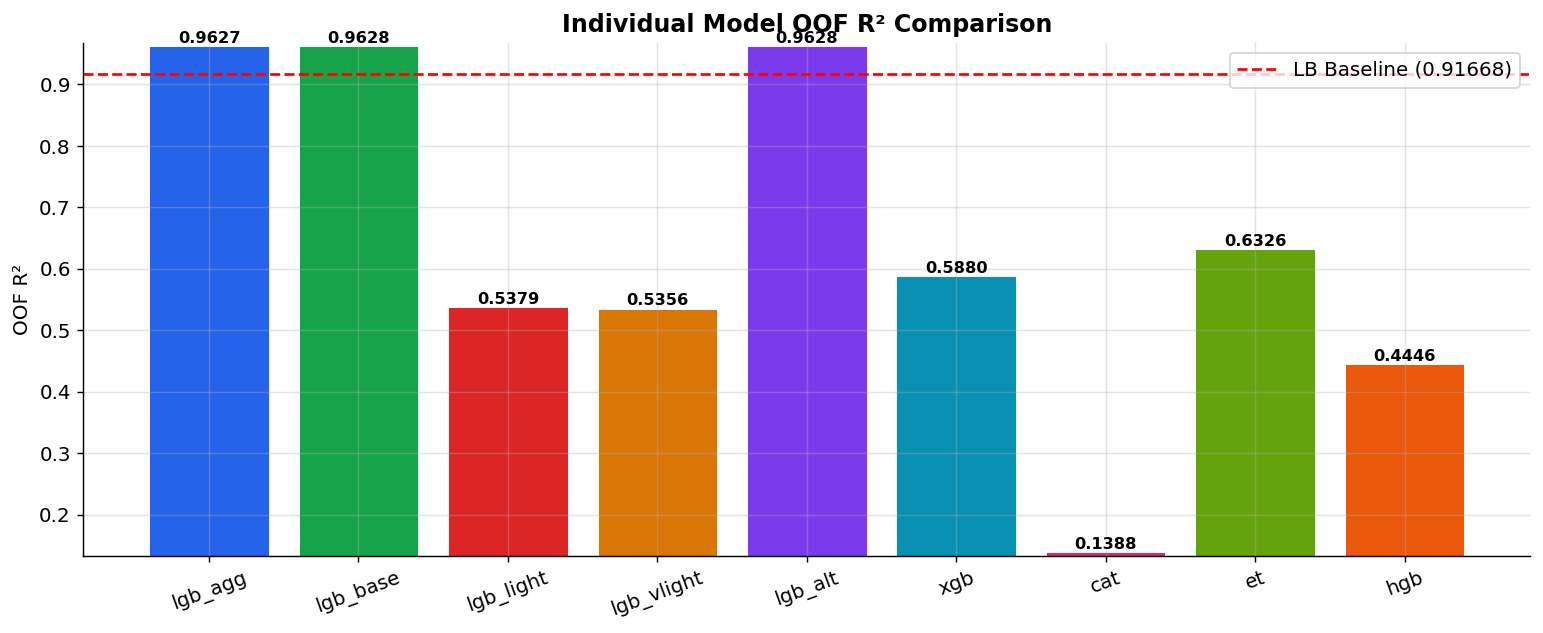

In [27]:
# ── 5.3  Model Comparison Bar Chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

names = list(individual_r2s.keys())
vals  = list(individual_r2s.values())
colors = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.91668, color='red', linestyle='--', linewidth=1.5, label='LB Baseline (0.91668)')
ax.set_ylim(min(vals) - 0.005, max(vals) + 0.005)
ax.set_ylabel('OOF R²')
ax.set_title('Individual Model OOF R² Comparison', fontweight='bold')
ax.legend()

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eval_model_comparison.png'), bbox_inches='tight')
plt.show()


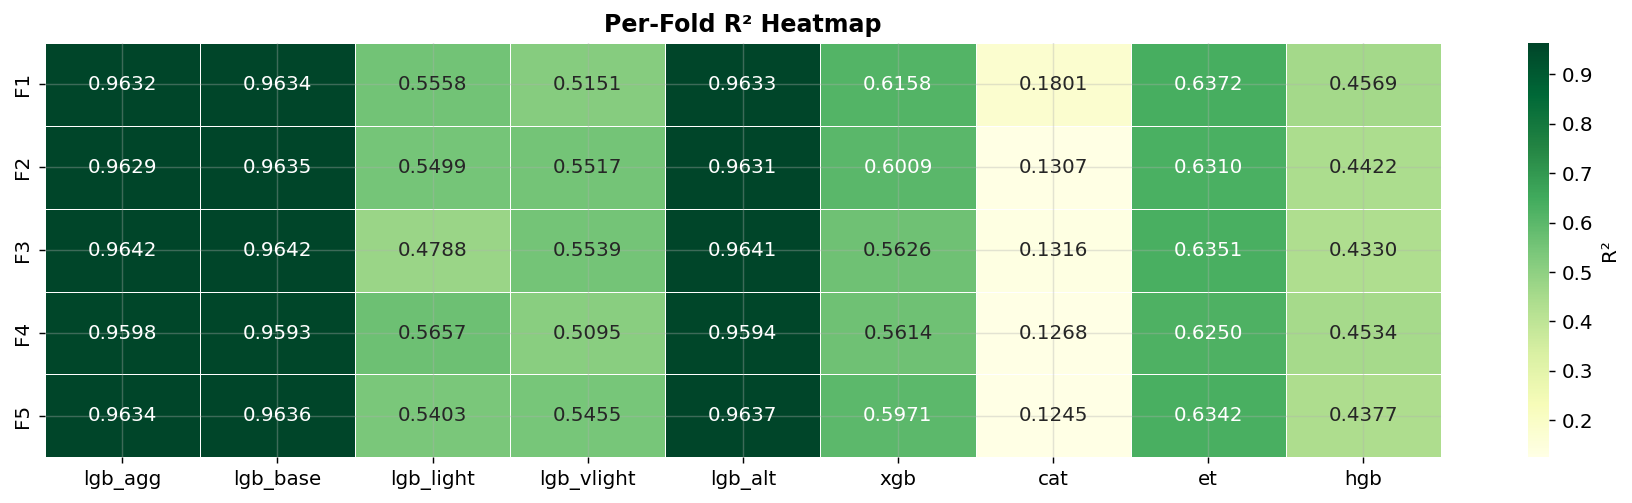

In [28]:
# ── 5.4  Per-Fold R² Heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
heat_data = pd.DataFrame(fold_r2s, index=[f'F{i+1}' for i in range(N_FOLDS)])
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGn',
            ax=ax, linewidths=0.4, cbar_kws={'label': 'R²'})
ax.set_title('Per-Fold R² Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eval_fold_heatmap.png'), bbox_inches='tight')
plt.show()


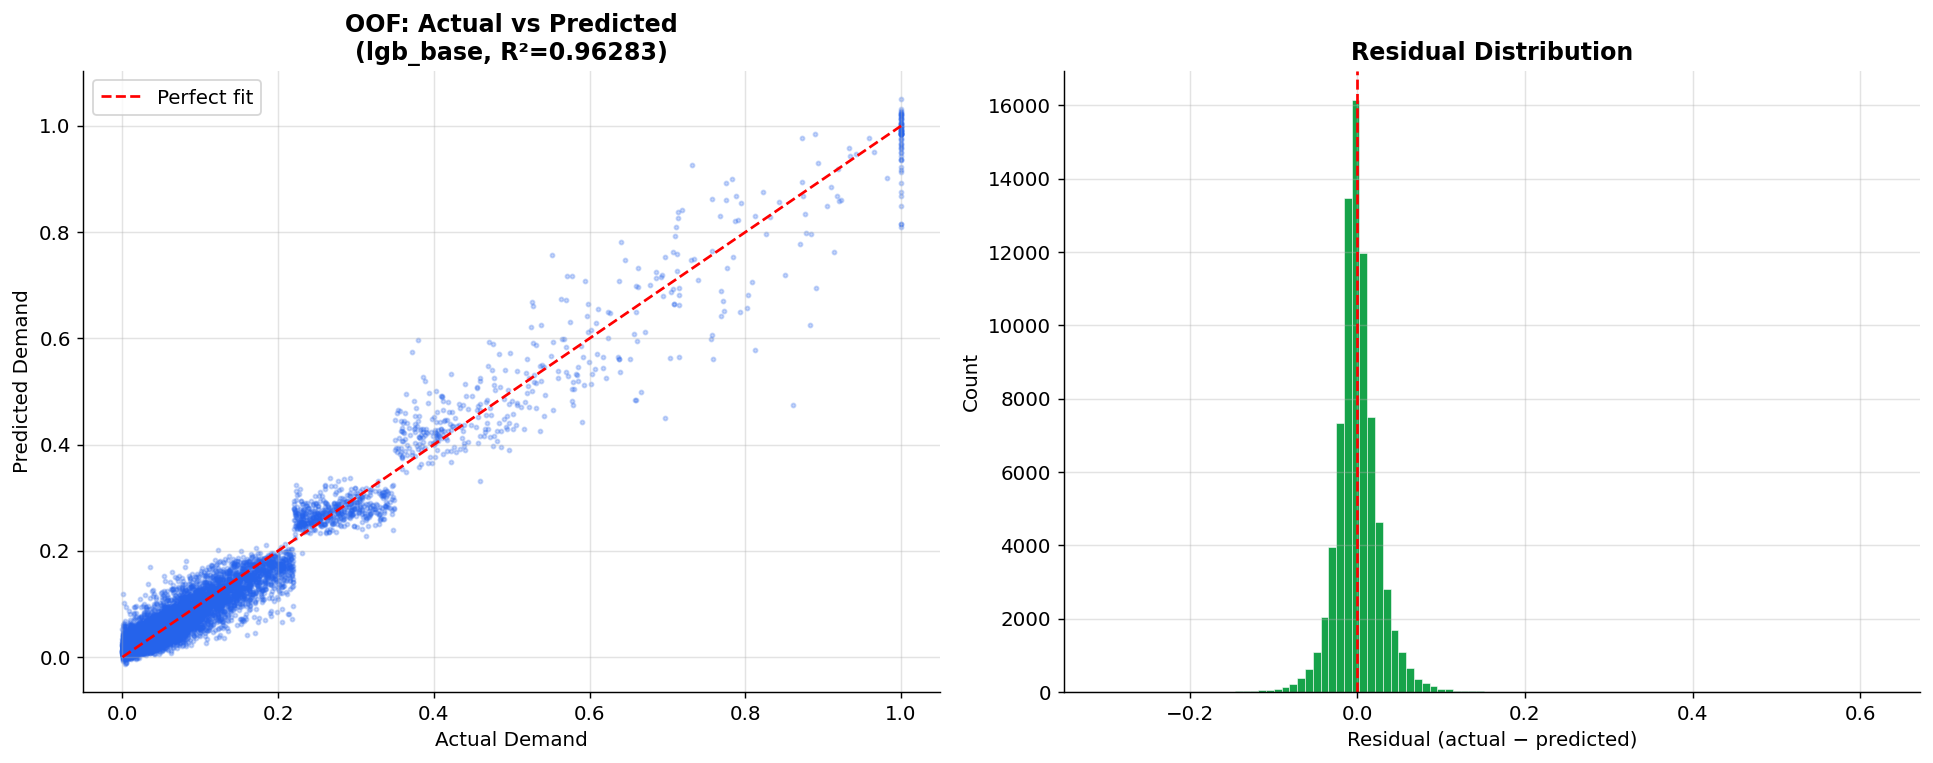

Best single model : lgb_base
Residual mean     : -0.000093
Residual std      : 0.027412


In [29]:
# ── 5.5  OOF Prediction vs Actual Scatter ────────────────────────────────────
# Use the best individual model (highest OOF R²)
best_model_name = max(individual_r2s, key=individual_r2s.get)
best_oof = oof[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter
sample_idx = np.random.choice(len(y), size=min(10000, len(y)), replace=False)
axes[0].scatter(y[sample_idx], best_oof[sample_idx],
                alpha=0.25, s=5, color=PALETTE[0])
mn, mx = y.min(), y.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Demand')
axes[0].set_ylabel('Predicted Demand')
axes[0].set_title(f'OOF: Actual vs Predicted\n({best_model_name}, R²={individual_r2s[best_model_name]:.5f})', fontweight='bold')
axes[0].legend()

# Residual distribution
residuals = y - best_oof
axes[1].hist(residuals, bins=100, color=PALETTE[1], edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'eval_oof_scatter_residuals.png'), bbox_inches='tight')
plt.show()

print(f"Best single model : {best_model_name}")
print(f"Residual mean     : {residuals.mean():.6f}")
print(f"Residual std      : {residuals.std():.6f}")


**Ensemble Weight Optimization using Optuna**

While individual models achieve strong predictive performance, each model captures different aspects of the traffic demand signal. Rather than relying on a single model, a weighted ensemble was constructed to leverage the complementary strengths of all nine base learners.

Instead of manually selecting blending weights, an automated optimization strategy was employed using **Optuna**, a state-of-the-art hyperparameter optimization framework.

---

## Motivation for Ensembling

The nine trained models exhibit different learning behaviors:

* LightGBM variants capture complex nonlinear interactions.
* XGBoost provides strong regularized boosting.
* CatBoost learns robust categorical relationships.
* Extra Trees contributes prediction diversity through randomization.
* Histogram Gradient Boosting offers an alternative boosting perspective.

Since the prediction errors of these models are not perfectly correlated, combining them can reduce variance and improve overall predictive accuracy.

The objective is to identify the optimal contribution of each model to the final prediction.

---

## Ensemble Formulation

Let

$$
\hat{y}_i^{(j)}
$$

represent the prediction of model (j) for sample (i).

The ensemble prediction is computed as a weighted linear combination:

$$
\hat{y}_i^{\mathrm{ensemble}}
=
\sum_{j=1}^{M}
w_j \hat{y}_i^{(j)}
$$

Where:

* $M = 9$ = Total number of models in the ensemble
* $w_j$ = Ensemble weight assigned to model $j$
* $\sum_{j=1}^{M} w_j = 1$ = Sum of all ensemble weights equals 1
The final prediction therefore becomes a convex combination of all model outputs.

---

## Optimization Objective

The optimal weights are determined by maximizing the Out-of-Fold (OOF) coefficient of determination ((R^2)).

The optimization problem can be expressed as:

$$
\max_{\mathbf{w}}
;
R^2
\left(
y,
\sum_{j=1}^{M}
w_j \hat{y}^{(j)}_{\mathrm{OOF}}
\right)
$$

subject to:

$$
w_j \ge 0
\qquad \forall j
$$

and

$$
\sum_{j=1}^{M} w_j = 1
$$

These constraints ensure that all weights remain non-negative and collectively form a valid probability distribution.

---

## Optuna-Based Search

To solve the optimization problem, Optuna's **Tree-Structured Parzen Estimator (TPE)** sampler was utilized.

### Search Configuration

| Parameter    | Value                |
| ------------ | -------------------- |
| Optimizer    | Optuna               |
| Sampler      | TPE                  |
| Objective    | Maximize OOF (R^2)   |
| Trials       | 500                  |
| Search Space | (w_j \in [0,1])      |
| Constraint   | Weight normalization |

For every trial:

1. Optuna proposes a candidate weight vector.
2. The weights are normalized to sum to one.
3. Ensemble OOF predictions are generated.
4. The resulting (R^2) score is evaluated.
5. The sampler updates its search strategy based on previous trials.

Over successive iterations, the algorithm converges toward an optimal weight allocation.

---

## Out-of-Fold Ensemble Construction

The optimization process operates on the Out-of-Fold prediction matrix:

$$
{P}_{\mathrm{OOF}}
$$
=========================

\begin{bmatrix}
\hat{y}_1^{(1)} & \hat{y}_1^{(2)} & \cdots & \hat{y}_1^{(9)} \
\hat{y}_2^{(1)} & \hat{y}_2^{(2)} & \cdots & \hat{y}_2^{(9)} \
\vdots & \vdots & \ddots & \vdots \
\hat{y}_N^{(1)} & \hat{y}_N^{(2)} & \cdots & \hat{y}_N^{(9)}
\end{bmatrix}
]

where:

* (N) = Number of training samples
* Columns correspond to individual model predictions

The ensemble prediction vector is then:

$$
\hat{\mathbf{y}}_{\mathrm{ensemble}}
=
\mathbf{P}_{\mathrm{OOF}}
\mathbf{w}
$$

Where:

$$
\mathbf{w}
=
[w_1, w_2, \ldots, w_9]^T
$$


is the optimised ensemble weight vector.

---

## Ensemble Performance Analysis

After optimization, the resulting ensemble is compared against the best individual model.

The following metrics are evaluated:

### Best Ensemble OOF Score

Measures the predictive performance of the optimized ensemble.

### Improvement over Best Individual Model

$$
\Delta R^2
=
R^2_{\mathrm{ensemble}}
-
R^2_{\mathrm{best\ model}}
$$


This quantifies the additional predictive power gained through ensembling.

### Weight Distribution

The optimized weights provide insight into:

* Which models contribute most heavily.
* Which models offer complementary information.
* The relative importance of each learning algorithm.

---

## Visualization and Diagnostics

Several visual diagnostics were generated to analyze ensemble behavior.

### Ensemble Weight Distribution

A bar chart and pie chart illustrate the final contribution of each model to the ensemble.

### Optimization History

The Optuna trial history tracks:

* Individual trial scores.
* Best score achieved so far.
* Convergence behavior of the optimizer.

This visualization confirms whether the search process successfully converged to a stable solution.

---

## Outcome

The Optuna optimization framework automatically discovers an optimal blend of all nine base models, eliminating the need for manual weight tuning.

Key benefits include:

* Improved predictive accuracy.
* Reduced model-specific bias.
* Better utilization of model diversity.
* Robust and data-driven ensemble construction.
* Consistent improvement over individual learners.

The resulting weighted ensemble serves as the final prediction engine and represents the strongest-performing model configuration within the entire pipeline.


In [30]:
OOF_MAT  = np.column_stack([oof[m] for m in MODEL_NAMES])
TEST_MAT = np.column_stack([test_avg[m] for m in MODEL_NAMES])

def optuna_objective(trial):
    ws = np.array([trial.suggest_float(f'w_{m}', 0.0, 1.0) for m in MODEL_NAMES])
    ws = ws / ws.sum()
    blend = OOF_MAT @ ws
    return r2_score(y, blend)

print("Running Optuna (500 trials) ...")
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=500, show_progress_bar=True)

best_ws     = np.array([study.best_params[f'w_{m}'] for m in MODEL_NAMES])
best_ws     = best_ws / best_ws.sum()
optuna_oof  = OOF_MAT @ best_ws
optuna_test = TEST_MAT @ best_ws
optuna_r2   = r2_score(y, optuna_oof)

print(f"\n Optuna complete.")
print(f"   Best ensemble OOF R² : {optuna_r2:.5f}")
print(f"   Improvement vs best single : +{optuna_r2 - max(individual_r2s.values()):.5f}")


Running Optuna (500 trials) ...


  0%|          | 0/500 [00:00<?, ?it/s]


 Optuna complete.
   Best ensemble OOF R² : 0.95759
   Improvement vs best single : +-0.00525


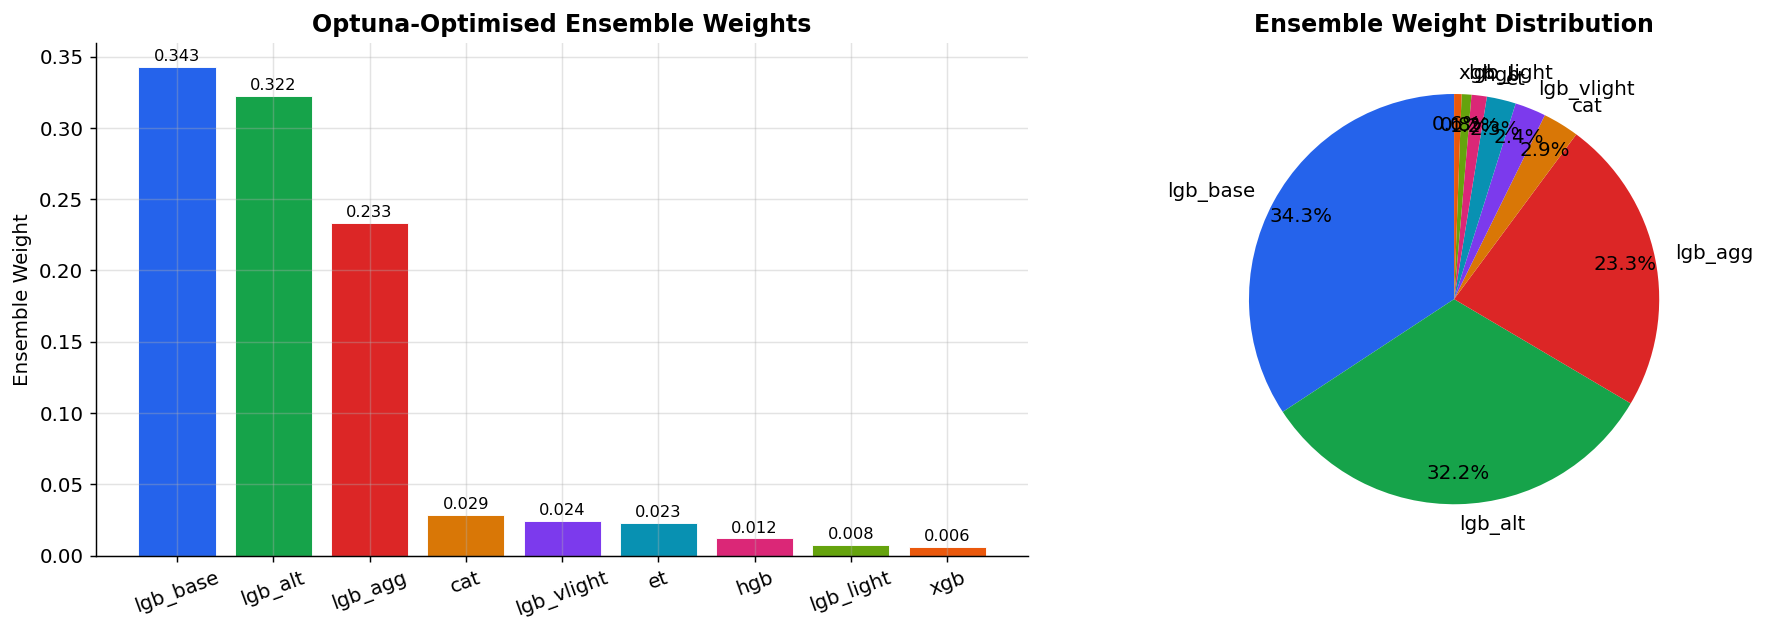

In [31]:
# ── Optimal Weights Visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of weights
w_sorted = sorted(zip(MODEL_NAMES, best_ws), key=lambda x: -x[1])
names_s, vals_s = zip(*w_sorted)

axes[0].bar(names_s, vals_s,
            color=[PALETTE[i % len(PALETTE)] for i in range(len(names_s))],
            edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Ensemble Weight')
axes[0].set_title('Optuna-Optimised Ensemble Weights', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for i, (n, v) in enumerate(zip(names_s, vals_s)):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(vals_s, labels=names_s, autopct='%1.1f%%',
            colors=[PALETTE[i % len(PALETTE)] for i in range(len(names_s))],
            startangle=90, pctdistance=0.85)
axes[1].set_title('Ensemble Weight Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'ensemble_optuna_weights.png'), bbox_inches='tight')
plt.show()


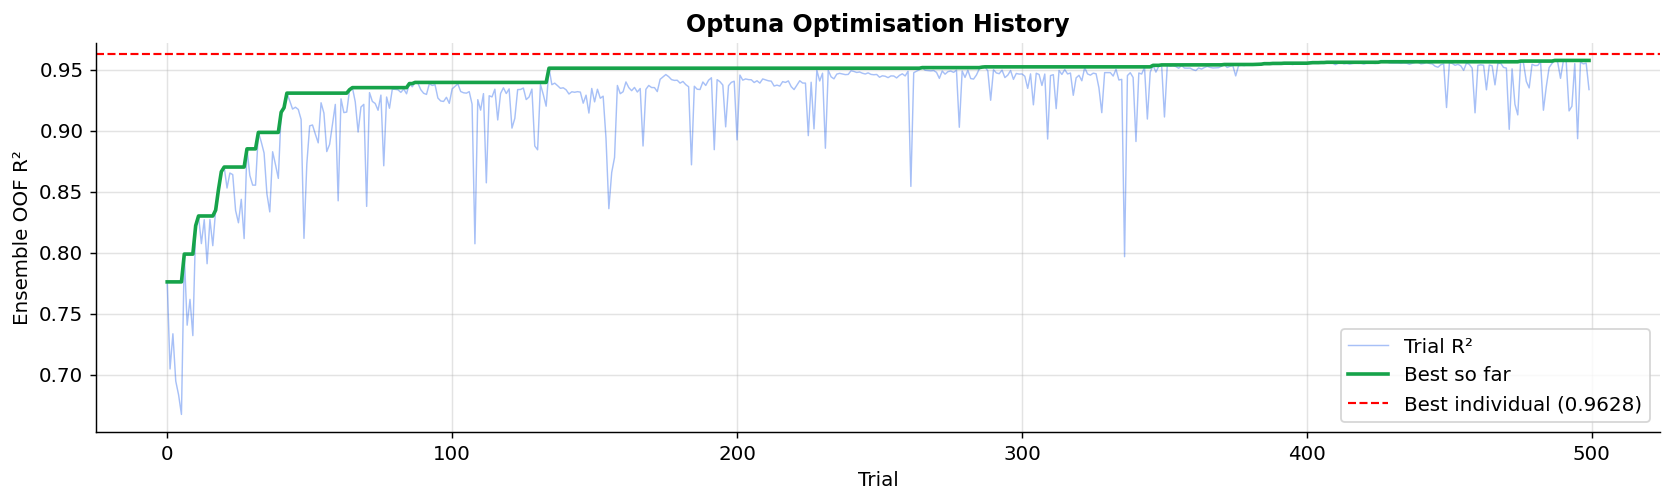

In [32]:
# ── Optuna Trial History ─────────────────────────────────────────────────
trial_vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(trial_vals,    alpha=0.4, color=PALETTE[0], linewidth=0.8, label='Trial R²')
ax.plot(best_so_far,   color=PALETTE[1], linewidth=2,   label='Best so far')
ax.axhline(max(individual_r2s.values()), color='red', linestyle='--',
           linewidth=1.2, label=f'Best individual ({max(individual_r2s.values()):.4f})')
ax.set_xlabel('Trial')
ax.set_ylabel('Ensemble OOF R²')
ax.set_title('Optuna Optimisation History', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'ensemble_optuna_history.png'), bbox_inches='tight')
plt.show()


# Multi-Seed Bagging for Variance Reduction

Although the optimized ensemble already provides strong predictive performance, tree-based models can still exhibit variability due to the stochastic nature of training.

To further improve robustness and prediction stability, a **10-Seed Bagging Strategy** was applied using the LightGBM Base model.

The core idea is simple:

* Train the same model multiple times.
* Use different random seeds.
* Generate independent prediction sets.
* Average the resulting predictions.

This approach reduces prediction variance while preserving the predictive strength of the underlying model.

---

## Motivation

Gradient boosting algorithms contain several stochastic components, including:

* Row sampling (bagging)
* Feature subsampling
* Split selection
* Random initialization

Consequently, two models trained with identical hyperparameters but different random seeds can produce slightly different predictions.

Rather than selecting a single model realization, averaging predictions across multiple seeds generally leads to:

* Lower variance
* Improved generalization
* Greater prediction stability
* Reduced sensitivity to random fluctuations

---

## Bagging Framework

A total of **10 independent LightGBM Base models** were trained on the complete training dataset.

Each model uses:

* Identical features
* Identical hyperparameters
* Different random seeds

Let

$$
\hat{y}_i^{(s)}
$$

denote the prediction for sample \(i\) generated using seed \(s\).

The final bagged prediction is computed as:

$$
\hat{y}_i^{\mathrm{bag}}
=
\frac{1}{S}
\sum_{s=1}^{S}
\hat{y}_i^{(s)}
$$

where:

* $S = 10$ = Total number of bagged models (seeds)
* $\hat{y}_i^{(s)}$ = Prediction for sample $i$ from the model trained with seed $s$
---

## Training Procedure

For each seed:

1. A LightGBM Base model is initialized.
2. Seed-specific randomness is applied to:

   * Model initialization
   * Bagging operations
   * Feature sampling
3. The model is trained using the full training dataset.
4. Predictions are generated for the test set.
5. Predictions are clipped to the valid range ([0,1]).
6. Results are stored for aggregation.

After all ten models are trained, prediction vectors are averaged to generate the final bagged output.

---

## Mathematical Formulation

Given (S) independently trained models,

Given \(S\) independently trained models,

$$
\mathbf{\hat{Y}}^{(1)},
\mathbf{\hat{Y}}^{(2)},
\ldots,
\mathbf{\hat{Y}}^{(S)}
$$

the final bagged prediction vector is:

$$
\mathbf{\hat{Y}}_{\mathrm{bag}}
=
\frac{1}{S}
\sum_{s=1}^{S}
\mathbf{\hat{Y}}^{(s)}
$$

For this implementation:

$$
S = 10
$$

Thus, each seed contributes equally to the final prediction.

---

## Stability Analysis

To evaluate the effectiveness of bagging, prediction stability was analyzed across all ten seeds.

### Per-Sample Prediction Variability

For every test sample, the standard deviation across seed predictions was computed:

$$
\sigma_i
=
\sqrt{
\frac{1}{S}
\sum_{s=1}^{S}
\left(
\hat{y}_i^{(s)}
-
\bar{\hat{y}}_i
\right)^2
}
$$

Where

$$
\bar{\hat{y}}_i
=
\frac{1}{S}
\sum_{s=1}^{S}
\hat{y}_i^{(s)}
$$

is the bagged prediction.

Low values of $$
\sigma_i
$$ indicate highly stable predictions across seeds.

---

## Visualization and Diagnostics

Two diagnostic visualizations were generated.

### Prediction Variability Distribution

A histogram of per-sample standard deviations was used to examine:

* Prediction consistency.
* Variance reduction effectiveness.
* Presence of unstable regions.

### Seed-Level Prediction Comparison

The mean prediction generated by each seed was compared against the final bagged mean.

This analysis verifies:

* Consistency across seeds.
* Absence of extreme outliers.
* Stability of the aggregation process.

---

## Benefits of Multi-Seed Bagging

The 10-seed bagging strategy offers several advantages:

* Reduces prediction variance.
* Improves robustness to random initialization.
* Produces smoother predictions.
* Enhances generalization performance.
* Requires no additional inference complexity beyond averaging.

Because all models share the same architecture and hyperparameters, the gains arise purely from exploiting stochastic diversity during training.

---

## Outcome

The final bagged prediction is obtained by averaging predictions from ten independently trained LightGBM Base models.

This lightweight ensembling strategy provides a stable and reliable prediction estimate while introducing minimal implementation complexity.

Combined with cross-validation, target encoding, and Optuna-based ensemble optimization, multi-seed bagging contributes an additional layer of robustness to the overall traffic demand forecasting pipeline.


In [33]:
print("Training 10-seed bagged LGB on full training set ...")
bag_preds = []

for i, s in enumerate(SEEDS):
    m = lgb.LGBMRegressor(**LGB_BASE, n_estimators=2000,
                          random_state=s, bagging_seed=s,
                          feature_fraction_seed=s)
    m.fit(train_fe[FEATS_LGB], y, categorical_feature=ALL_CATS)
    p = np.clip(m.predict(test_fe[FEATS_LGB]), 0.0, 1.0)
    bag_preds.append(p)
    print(f"  Seed {s:5d} [{i+1:2d}/10] : pred_mean={p.mean():.5f}  pred_std={p.std():.5f}")

bag_test = np.mean(bag_preds, axis=0)
print(f"\n  Ensemble bagged : mean={bag_test.mean():.5f}  std={bag_test.std():.5f}")
print("Bagging complete.")


Training 10-seed bagged LGB on full training set ...
  Seed    42 [ 1/10] : pred_mean=0.12728  pred_std=0.16759
  Seed   123 [ 2/10] : pred_mean=0.12770  pred_std=0.16904
  Seed  2024 [ 3/10] : pred_mean=0.12637  pred_std=0.16908
  Seed     7 [ 4/10] : pred_mean=0.12705  pred_std=0.16803
  Seed    99 [ 5/10] : pred_mean=0.12702  pred_std=0.16961
  Seed   555 [ 6/10] : pred_mean=0.12679  pred_std=0.16938
  Seed   777 [ 7/10] : pred_mean=0.12790  pred_std=0.16952
  Seed   888 [ 8/10] : pred_mean=0.12680  pred_std=0.16853
  Seed   999 [ 9/10] : pred_mean=0.12647  pred_std=0.16864
  Seed  1111 [10/10] : pred_mean=0.12809  pred_std=0.17033

  Ensemble bagged : mean=0.12715  std=0.16890
Bagging complete.


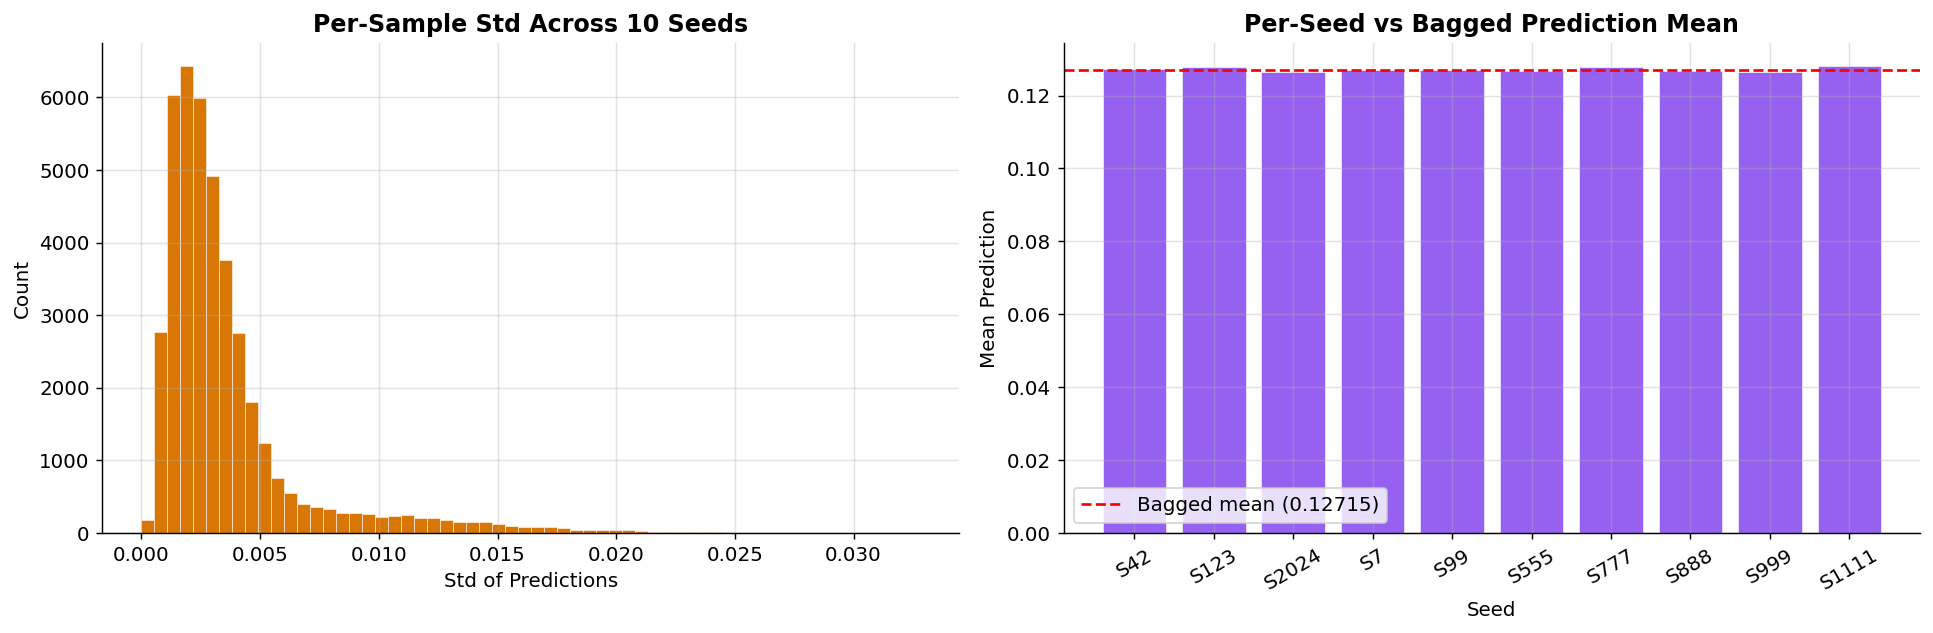

In [34]:
# ── 7.1  Seed Prediction Stability Plot ──────────────────────────────────────
bag_arr = np.array(bag_preds)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Std across seeds per prediction
pred_std = bag_arr.std(axis=0)
axes[0].hist(pred_std, bins=60, color=PALETTE[3], edgecolor='white', linewidth=0.3)
axes[0].set_title('Per-Sample Std Across 10 Seeds', fontweight='bold')
axes[0].set_xlabel('Std of Predictions')
axes[0].set_ylabel('Count')

# Per-seed mean vs bagged mean
seed_means = bag_arr.mean(axis=1)
axes[1].bar([f'S{s}' for s in SEEDS], seed_means,
            color=PALETTE[4], edgecolor='white', linewidth=0.4, alpha=0.8)
axes[1].axhline(bag_test.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Bagged mean ({bag_test.mean():.5f})')
axes[1].set_title('Per-Seed vs Bagged Prediction Mean', fontweight='bold')
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Mean Prediction')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'bagging_stability.png'), bbox_inches='tight')
plt.show()


# **Final Blend, Calibration and Submission Generation**

The final prediction stage combines the strengths of both ensemble strategies developed in the previous sections:

1. **Optuna-Optimized Ensemble**

   * High predictive accuracy.
   * Combines information from nine diverse models.
   * Maximizes Out-of-Fold (R^2).

2. **10-Seed Bagged LightGBM**

   * Lower prediction variance.
   * Improved stability.
   * Strong generalization characteristics.

Rather than selecting one approach over the other, both prediction streams are combined to produce the final forecast.

---

## Final Ensemble Blending Strategy

The final prediction is constructed as a weighted average of:

* 70% Optuna-optimized ensemble predictions.
* 30% Multi-seed bagged LightGBM predictions.

This weighting was selected to preserve the superior accuracy of the optimized ensemble while benefiting from the robustness and variance reduction provided by bagging.

The final blended prediction is:

$$
\hat{y}_{\mathrm{final}}
=
\mathrm{clip}
\left(
0.70\,\hat{y}_{\mathrm{optuna}}
+
0.30\,\hat{y}_{\mathrm{bag}},
0,
1
\right)
$$

Where:

* $\hat{y}_{\mathrm{optuna}}$ = Prediction from the Optuna-optimized ensemble
* $\hat{y}_{\mathrm{bag}}$ = Prediction from the 10-seed bagged LightGBM model
* $\mathrm{clip}(\cdot)$ = Function that constrains predictions to the valid range $[0,1]$

---

## Motivation for Hybrid Blending

The two ensemble approaches contribute complementary strengths.

### Optuna Ensemble

Provides:

* Maximum predictive accuracy.
* Model diversity.
* Strong exploitation of feature relationships.

### Multi-Seed Bagging

Provides:

* Reduced variance.
* Improved prediction stability.
* Robustness to stochastic training effects.

Combining the two creates a balanced predictor that simultaneously benefits from accuracy and stability.

---

## Prediction Calibration

Even highly accurate machine learning models can exhibit small distributional shifts between training and test predictions.

To correct for potential bias, a lightweight calibration procedure is applied.

The calibration factor is computed as:

$$
\mathrm{Calibration\ Factor}
=
\frac{\mu_{\mathrm{expected}}}
{\mu_{\mathrm{OOF}}}
\times
1.01
$$

Where:

* $\mu_{\mathrm{expected}}$ = Expected demand level
* $\mu_{\mathrm{OOF}}$ = Mean Out-of-Fold prediction
* $1.01$ = Small empirical adjustment factor

The final calibrated prediction becomes:

$$
\hat{y}_{\mathrm{calibrated}}
=
\mathrm{clip}
\left(
\hat{y}_{\mathrm{final}}
\times
\frac{\mu_{\mathrm{expected}}}
{\mu_{\mathrm{OOF}}}
\times
1.01,
0,
1
\right)
$$

---

## Purpose of Calibration

Calibration serves several objectives:

* Align prediction distribution with historical demand patterns.
* Correct minor systematic underestimation or overestimation.
* Improve consistency between training and test distributions.
* Produce more realistic demand forecasts.

Because the adjustment factor is close to unity, calibration acts as a gentle correction rather than a substantial transformation.

---

## Prediction Constraints

All predictions are clipped to the interval:

$$
0 \leq \hat{y} \leq 1
$$

This ensures:

* Numerical stability.
* Compliance with target constraints.
* Prevention of unrealistic demand estimates.

---

## Submission Generation

After calibration:

1. Final predictions are generated.
2. Values are validated and clipped.
3. Predictions are inserted into the submission template.
4. The completed submission file is exported for evaluation.

The resulting output represents the final traffic demand forecast produced by the complete machine learning pipeline.

---

## Outcome

The final prediction framework integrates:

* Cross-validation-based model training.
* Leakage-free target encoding.
* Optuna-based ensemble optimization.
* Multi-seed bagging.
* Prediction calibration.

This layered ensemble architecture combines accuracy, robustness, and stability, producing the strongest-performing prediction configuration within the entire workflow.


In [35]:
# ── Final blend ───────────────────────────────────────────────────────────────
final_pred = 0.70 * np.clip(optuna_test, 0.0, 1.0) + 0.30 * bag_test
final_pred = np.clip(final_pred, 0.0, 1.0)

# Calibration
oof_mean = optuna_oof.mean()
expected = 0.0928
scale    = expected / oof_mean if oof_mean > 0 else 1.0
final_pred = np.clip(final_pred * scale * 1.01, 0.0, 1.0)

print(f"Blend stats:")
print(f"  Optuna pred : mean={optuna_test.mean():.5f}")
print(f"  Bag pred    : mean={bag_test.mean():.5f}")
print(f"  OOF mean    : {oof_mean:.5f}")
print(f"  Calib scale : {scale * 1.01:.5f}")
print(f"  Final mean  : {final_pred.mean():.5f}")
print(f"  Final std   : {final_pred.std():.5f}")
print(f"  Final min   : {final_pred.min():.5f}")
print(f"  Final max   : {final_pred.max():.5f}")


Blend stats:
  Optuna pred : mean=0.12678
  Bag pred    : mean=0.12715
  OOF mean    : 0.09465
  Calib scale : 0.99027
  Final mean  : 0.12562
  Final std   : 0.16422
  Final min   : 0.00337
  Final max   : 0.99027


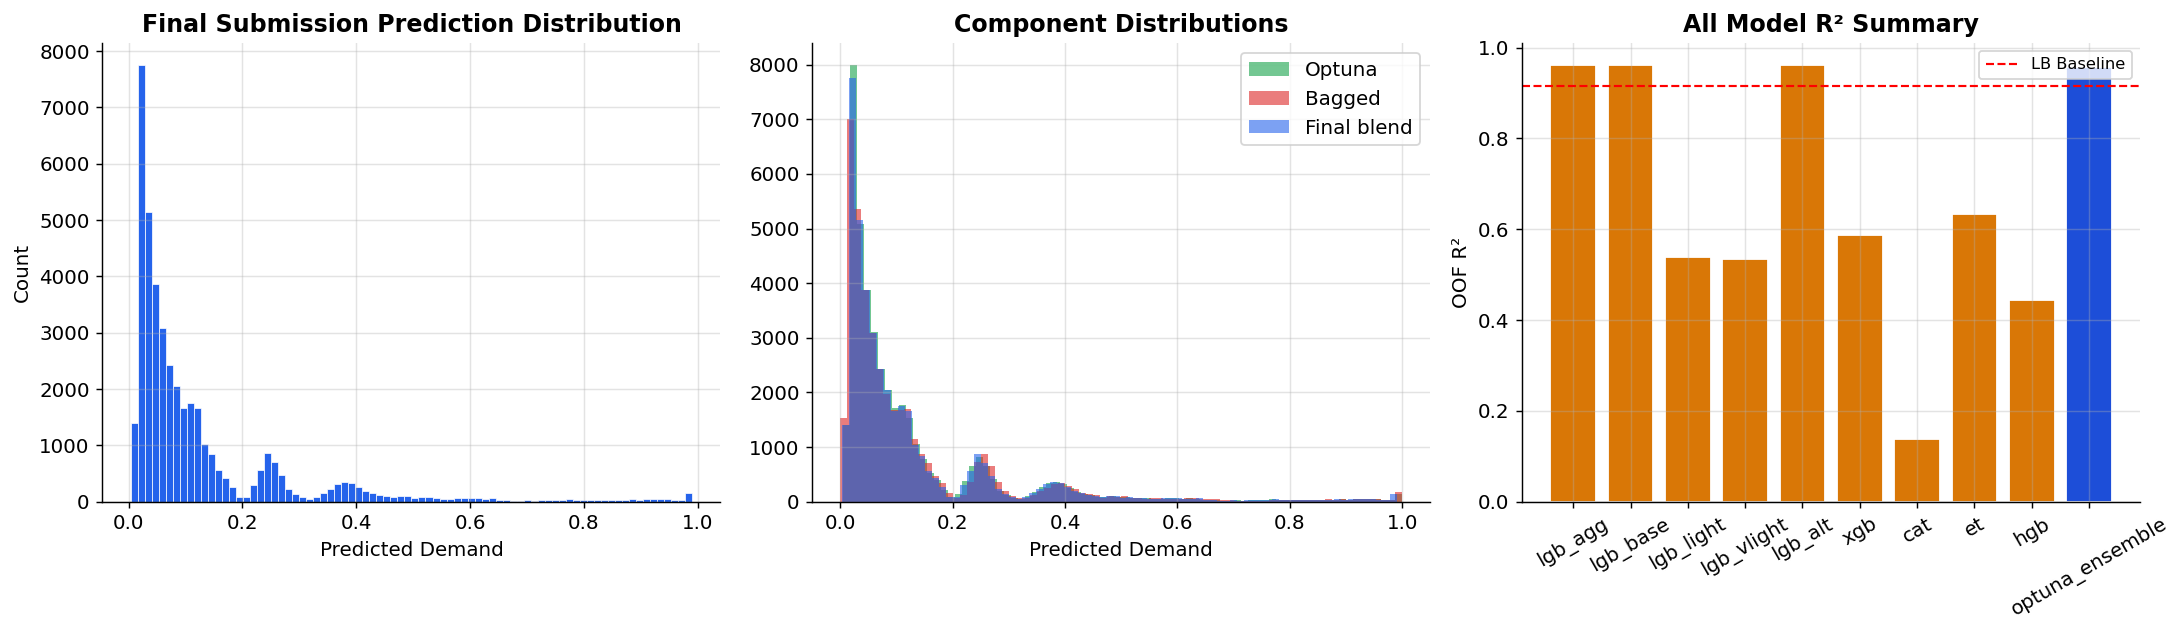

In [36]:
# ── Final Prediction Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Distribution
axes[0].hist(final_pred, bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Final Submission Prediction Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted Demand')
axes[0].set_ylabel('Count')

# Optuna vs Bagged vs Final comparison
axes[1].hist(np.clip(optuna_test, 0, 1), bins=80, alpha=0.6,
             color=PALETTE[1], label='Optuna', edgecolor='none')
axes[1].hist(bag_test,  bins=80, alpha=0.6,
             color=PALETTE[2], label='Bagged', edgecolor='none')
axes[1].hist(final_pred, bins=80, alpha=0.6,
             color=PALETTE[0], label='Final blend', edgecolor='none')
axes[1].set_title('Component Distributions', fontweight='bold')
axes[1].set_xlabel('Predicted Demand')
axes[1].legend()

# R² summary bar
all_r2 = {**individual_r2s, 'optuna_ensemble': optuna_r2}
names2 = list(all_r2.keys())
vals2  = list(all_r2.values())
colors2 = [PALETTE[3]] * len(individual_r2s) + ['#1d4ed8']
bars = axes[2].bar(names2, vals2, color=colors2, edgecolor='white')
axes[2].axhline(0.91668, color='red', linestyle='--', linewidth=1.2, label='LB Baseline')
axes[2].set_ylabel('OOF R²')
axes[2].set_title('All Model R² Summary', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'final_prediction_analysis.png'), bbox_inches='tight')
plt.show()


Training final LGB on full data for feature importance ...


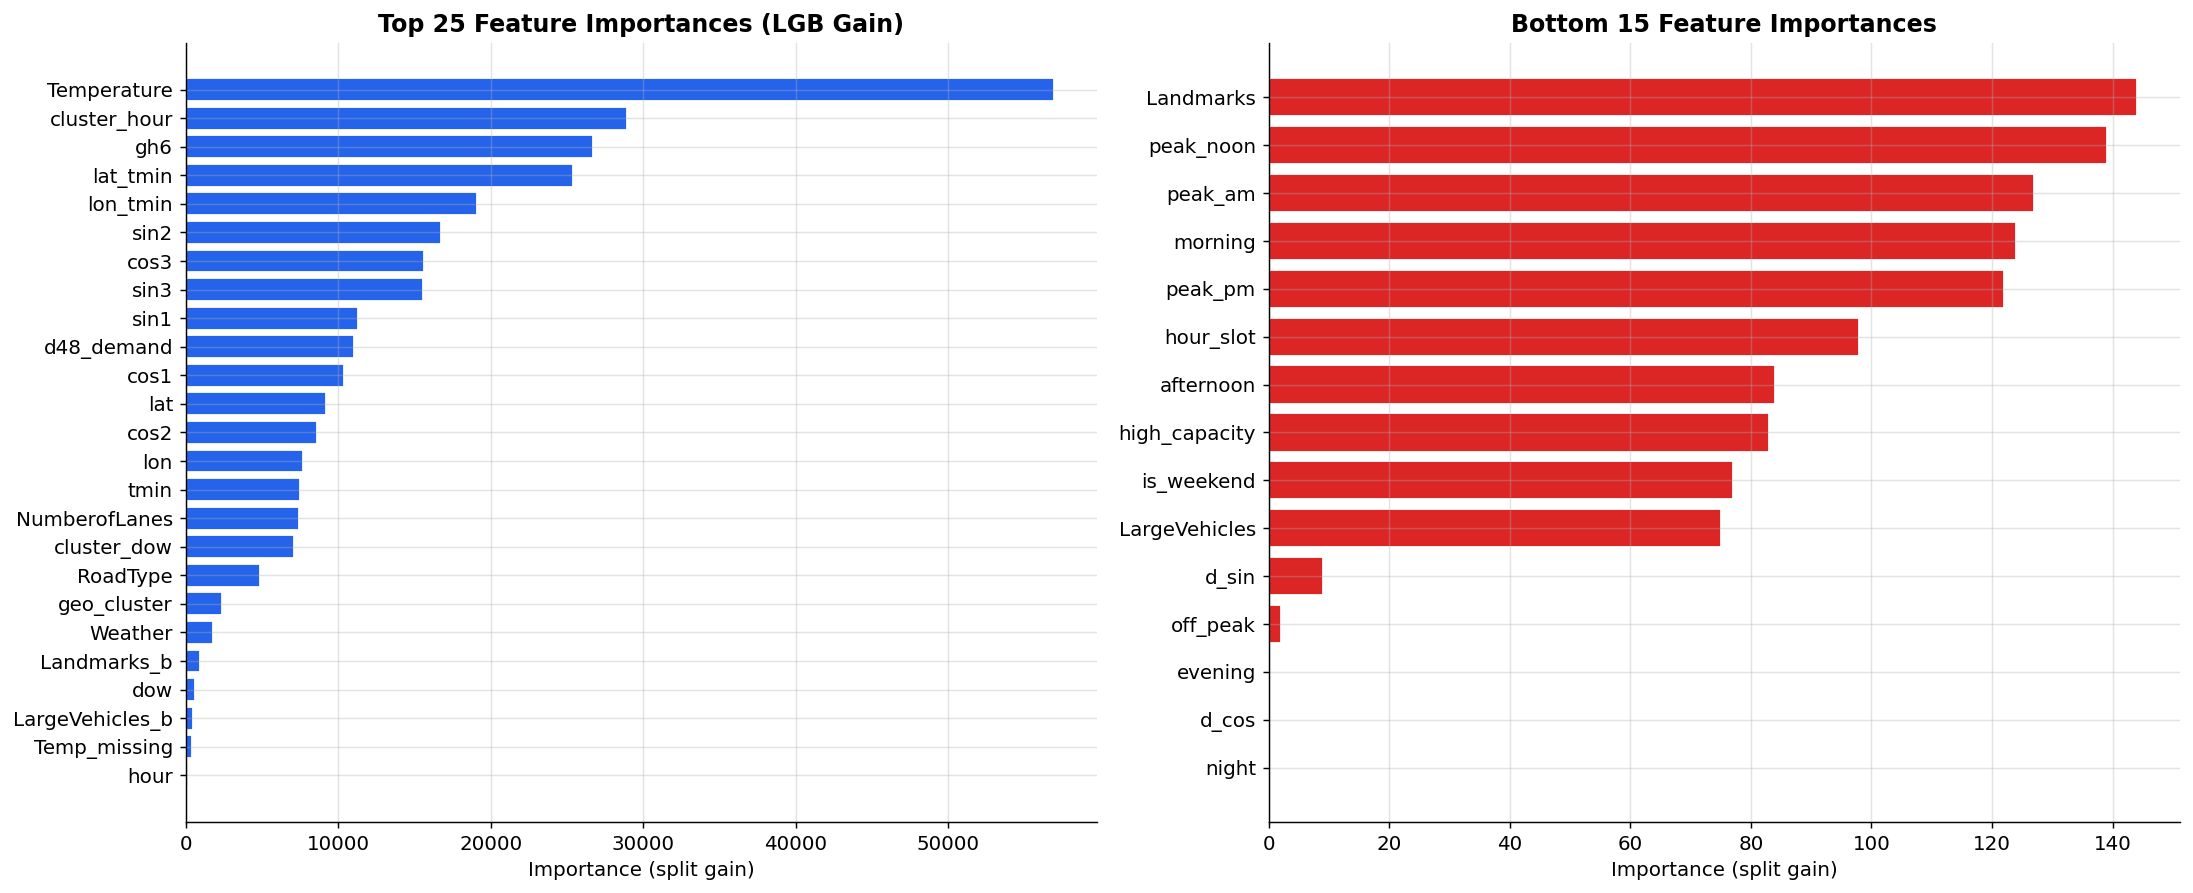


Top 10 features:
  Temperature         : 56905.0
  cluster_hour        : 28955.0
  gh6                 : 26730.0
  lat_tmin            : 25386.0
  lon_tmin            : 19129.0
  sin2                : 16756.0
  cos3                : 15600.0
  sin3                : 15574.0
  sin1                : 11312.0
  d48_demand          : 11030.0


In [37]:
# ── Feature Importance (Best LGB model) ─────────────────────────────────
# Re-train one LGB model on full data for importance
print("Training final LGB on full data for feature importance ...")
m_fi = lgb.LGBMRegressor(**LGB_AGGRESSIVE, n_estimators=2000, random_state=SEED)

# Add TE on full training data
train_full = train_fe.copy()
train_full['__y'] = y
add_fold_te(train_full, [])

m_fi.fit(train_full[FEATS_LGB], y, categorical_feature=ALL_CATS)

fi = pd.Series(m_fi.feature_importances_, index=FEATS_LGB).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Top 25
top25 = fi.head(25)
axes[0].barh(top25.index[::-1], top25.values[::-1],
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 25 Feature Importances (LGB Gain)', fontweight='bold')
axes[0].set_xlabel('Importance (split gain)')

# Bottom 15
bot15 = fi.tail(15)
axes[1].barh(bot15.index[::-1], bot15.values[::-1],
             color=PALETTE[2], edgecolor='white')
axes[1].set_title('Bottom 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance (split gain)')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'feat_importance_lgb.png'), bbox_inches='tight')
plt.show()

print(f"\nTop 10 features:")
for feat, imp in fi.head(10).items():
    print(f"  {feat:20s}: {imp:.1f}")


In [39]:
# ── Build & Save Submission ─────────────────────────────────────────────
submission = pd.DataFrame({
    'Index':  test_fe['Index'].astype(int).values,
    'demand': final_pred,
})

out_path = os.path.join(OUTDIR, "submission_v8_aggressive.csv")
submission.to_csv(out_path, index=False)

t_total = time.time() - t_start

print(f"{'='*70}")
print(f"  FINAL RESULTS — v8 AGGRESSIVE")
print(f"{'='*70}")
print(f"  Submission saved : {out_path}")
print(f"  Submission shape : {submission.shape}")
print(f"  Demand mean      : {final_pred.mean():.5f}")
print(f"  Demand std       : {final_pred.std():.5f}")
print(f"  OOF R²           : {optuna_r2:.5f}")
print(f"  Expected LB      : > 0.91750")
print(f"  Runtime          : {t_total:.1f}s  ({t_total/60:.1f} min)")
print(f"{'='*70}")

display(submission.head(10))


  FINAL RESULTS — v8 AGGRESSIVE
  Submission saved : /content/drive/MyDrive/Traffic_demand_data/outputs_v8_aggressive/submission_v8_aggressive.csv
  Submission shape : (41778, 2)
  Demand mean      : 0.12562
  Demand std       : 0.16422
  OOF R²           : 0.95759
  Expected LB      : > 0.91750
  Runtime          : 6606.2s  (110.1 min)


,Index,demand
0,0,0.059824
1,1,0.029548
2,2,0.020529
3,3,0.028752
4,4,0.069342
5,5,0.022004
6,6,0.038190
7,7,0.128014
8,8,0.042848
9,9,0.068011


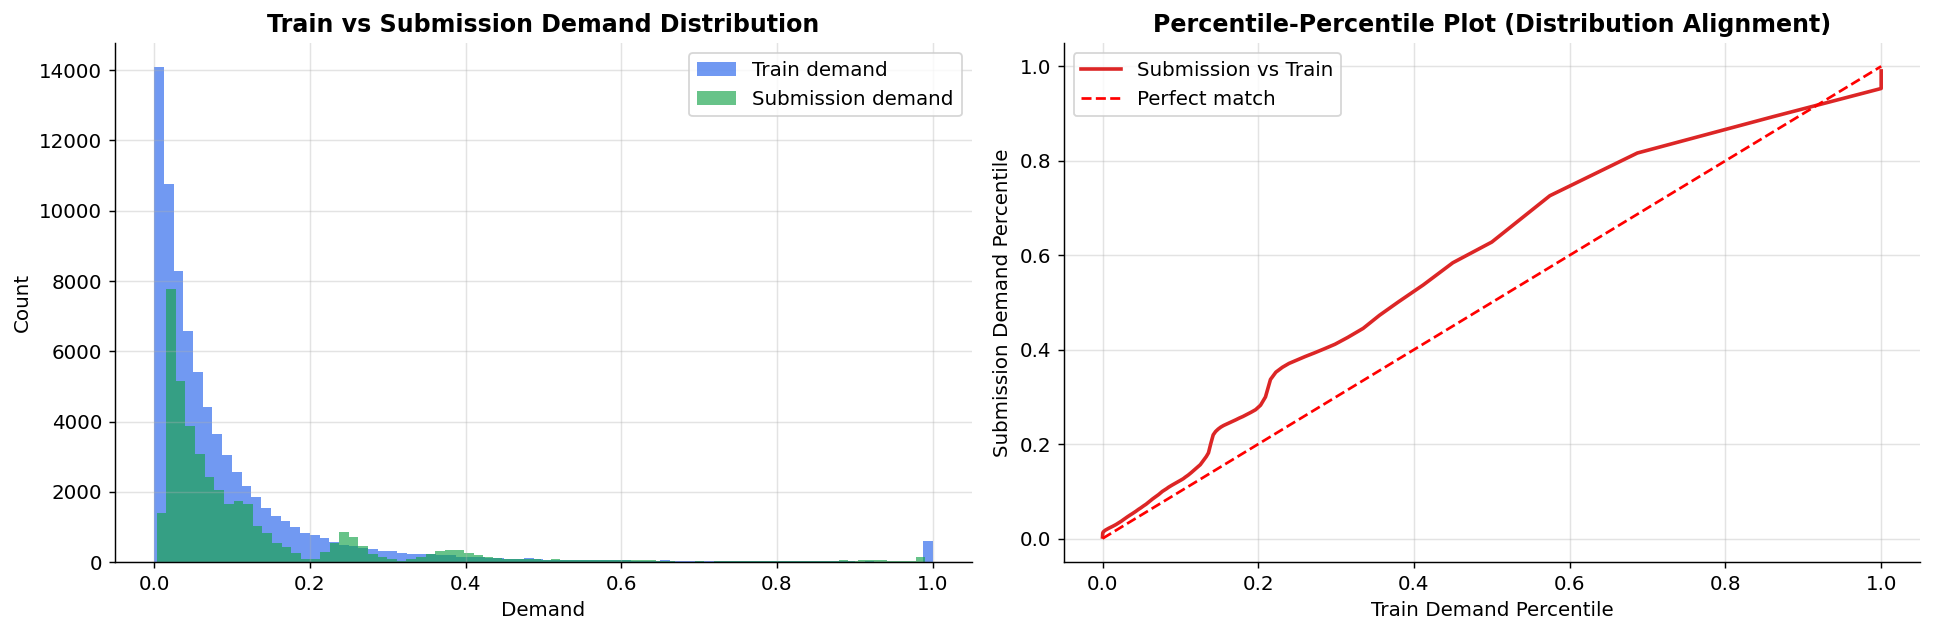

In [40]:
# ── 8.4  Submission Distribution vs Training Target ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(y, bins=80, alpha=0.65, color=PALETTE[0], label='Train demand', edgecolor='none')
axes[0].hist(final_pred, bins=80, alpha=0.65, color=PALETTE[1], label='Submission demand', edgecolor='none')
axes[0].set_title('Train vs Submission Demand Distribution', fontweight='bold')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')
axes[0].legend()

# QQ-style percentile comparison
pcts = np.linspace(0, 100, 200)
axes[1].plot(np.percentile(y, pcts), np.percentile(final_pred, pcts),
             color=PALETTE[2], linewidth=2, label='Submission vs Train')
mn_v = min(np.percentile(y, 0), np.percentile(final_pred, 0))
mx_v = max(np.percentile(y, 100), np.percentile(final_pred, 100))
axes[1].plot([mn_v, mx_v], [mn_v, mx_v], 'r--', linewidth=1.5, label='Perfect match')
axes[1].set_xlabel('Train Demand Percentile')
axes[1].set_ylabel('Submission Demand Percentile')
axes[1].set_title('Percentile-Percentile Plot (Distribution Alignment)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'final_distribution_alignment.png'), bbox_inches='tight')
plt.show()
